[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd6-pm/06_capstone_health_condition_classifiers.ipynb)

# 06. Capstone descriptive classifiers and leakage audit

**Research use only.** This tutorial does not diagnose a person or validate a clinical device.

## The question this notebook answers

What structure can a frozen final curriculum encoder expose through simple Random Forest readouts, and how much of that structure might come from something other than gait, namely detector missingness, source-video identity, or the encoder's own prior exposure to the evaluation rows?

## Read this before any score appears

**Every readout in this notebook is DESCRIPTIVE.** The final encoder was fine-tuned with condition labels on the curriculum corpus, so unless notebook 04 is rerun inside each outer training fold, a classifier score on those rows is a transductive, label-informed description, not test performance. This is not a hedge added at the end; it is the reason the notebook is organized into lanes at all.

Two rules govern everything below:

1. **The source video, not the sequence, is the independent unit of evidence.** The canonical corpus has 96 sequences but only 18 source videos, and normal comes from exactly one.
2. **Folder labels are dataset annotations, not clinical diagnoses.** Nothing here was diagnosed or verified by a clinician for this tutorial.

## The evaluation lanes, and what each one is for

The notebook runs several readouts, not because more numbers are better, but because each lane closes one specific escape route and leaves others open. Learn to read the lane before you read its score.

| Lane | How it splits | What it removes | What it leaves in | What it licenses |
|---|---|---|---|---|
| **A1, all-96 stratified** | 96 canonical **sequences** into 67 train / 29 test, class-stratified | class-mixture imbalance between the two sides | source-video overlap, and full encoder exposure | that a shallow classifier can recover the labels from these embeddings on a fixed sequence partition |
| **A2, exact exp5** | the 68 exp5 **sequences** into 47 train / 21 test, using the legacy permutation | nothing new; it exists to be comparable with the exp5 baseline | source-video overlap, and full encoder exposure | a like-for-like row comparison against the saved handcrafted result |
| **B, source-disjoint five-class on the canonical corpus** | would split whole **videos** | source-video overlap | encoder exposure | **nothing. It cannot run**, because canonical normal has one source video |
| **C, source-disjoint at the Random Forest only** | whole **videos**, over the 159-row canonical-plus-augmented corpus | source-video overlap from the classifier split | **encoder exposure: the encoder still saw all 159 rows** | that the readout survives when whole videos move to the other side of the classifier split |
| **Missingness-only control** | same indices as the lane it audits | all gait geometry, by construction | detector-failure patterns | a **shortcut floor**: the score reachable from pose-visibility patterns alone |
| **Majority-class control** | none | everything | nothing | the weakest possible bar |

The two things to internalize:

- **A1 and A2 split sequences while sharing videos and prior encoder exposure.** They are the optimistic lanes. Their numbers are real measurements of a real thing, but that thing is "recoverability inside an already-seen corpus", not generalization.
- **Lane C separates videos only at the Random Forest.** Grouping fixes the classifier split. It does not and cannot undo the fact that notebook 04's encoder was trained on every one of those 159 rows, with their labels from Stage 1 onward. Lane C is a stronger stress test than A1 or A2 and is still not an independent evaluation.

**A lane that cannot run is a finding, not an omission.** Lane B is blocked by the cohort, and the notebook prints that rather than quietly skipping it. Recording why an analysis is unavailable is what stops a reader from assuming it was run and passed.

## What you need before you start

A completed final checkpoint from notebook 04, and notebook 05 read first so you already know the geometry is weak. The checkpoint cohort is selected by `SJEPA_INCLUDE_AUGMENTED_NORMAL`, with `SJEPA_CLASSIFIER_CHECKPOINT` as an explicit override.

## What it produces

Per-lane metric CSVs, classification reports, confusion matrices and their PNGs, error tables, the missingness-only audit, `leakage_audit.csv`, `lane_c_video_disjoint_metrics.csv`, the fitted Random Forests as joblib files, `classifier_contract.json` recording every split by sequence ID, and a summary evidence-ladder SVG.

## The sixteen steps

1. Point the notebook at the data and choose the run mode.
2. Restate the shared definitions and the exp5 row order.
3. Frame the capstone question.
4. Load the frozen encoder and the canonical corpus.
5. Build the missingness-only shortcut floor.
6. Freeze and pool one vector per sequence.
7. Fix one Random Forest specification so the lanes are comparable.
8. Lane A1: all-96 stratified.
9. Lane A2: the exact exp5 split.
10. Audit source-video overlap and encoder exposure.
11. Read the five-class confusion matrix.
12. Fit four one-versus-normal readouts.
13. Lane B and Lane C: what video grouping does and does not fix.
14. Compare with the checked exp5 result.
15. Save every model, metric, and split contract.
16. Assemble the results and the discussion.


## Step 1 of 16: point the notebook at the data and choose the run mode

**What we are about to do.** Resolve the repository root, load `.env`, decide between `smoke` and `real` mode, and locate the artifact directory notebook 04 wrote into.

**Why this comes first.** Every checkpoint, embedding, metric, and fitted model in this notebook is read from or written to `ARTIFACT_DIR`, which depends on the mode. Deciding the mode before touching data is what keeps a smoke run from overwriting real results.

**What to look at in the output.** `mode:` must read `real`, and `artifacts:` must match the directory notebooks 04 and 05 reported. The next cell's figure is the evaluation protocol this notebook implements.

**What we may conclude.** Only that the environment is consistent with the earlier notebooks.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TUTORIAL_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm"

try:
    from dotenv import load_dotenv
    load_dotenv(TUTORIAL_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd6-pm" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", TUTORIAL_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", TUTORIAL_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

# ---------------------------------------------------------------------------
# Optional augmentation-normal cohort (opt-in; default OFF).
#
# The self-annotated data-videos/normal clips are pose-extracted by
# notes/extract_augmented_poses.py into a SEPARATE pose folder and pretrained
# into a SEPARATE checkpoint by notebook 04. This flag surfaces that cohort in
# an ADDITIVE "Lane C" only. When it is off (the default), every locked
# canonical lane (A1/A2/binary/leakage and their 96/18, 47/21, shared==9
# asserts) keeps the same canonical sequence rows. The flag selects the matching
# final encoder variant for every lane. When it is on, the canonical
# arrays still stay canonical-only; the augmentation cohort is carried in
# separate parallel arrays so the canonical numbers never move.
#
# Truthy set matches notebook 04 exactly: {"1","true","yes","on"}.
# ---------------------------------------------------------------------------
INCLUDE_AUGMENTED_NORMAL = os.getenv(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"
MIN_AUGMENTED_NEURO_OBSERVED = 0.45
# Notebook 04 writes an augmentation-broadened encoder to a distinct file so
# the canonical checkpoint is never overwritten. The downstream selector
# requires the variant requested by the flag and never silently falls back.
CANONICAL_CHECKPOINT = ARTIFACT_DIR / "sjepa_curriculum_final.pt"
AUGMENTED_CHECKPOINT = ARTIFACT_DIR / "sjepa_curriculum_final_augmented.pt"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = TUTORIAL_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")
print(
    "augmentation-normal cohort: "
    + ("ENABLED (Lane C additive)" if INCLUDE_AUGMENTED_NORMAL else "disabled")
)


mode: real
project: /Users/pmui/dev/alexpose
GAVD CSVs: /Users/pmui/dev/alexpose/data/gavd
YouTube cache: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/youtube
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real
augmentation-normal cohort: ENABLED (Lane C additive)


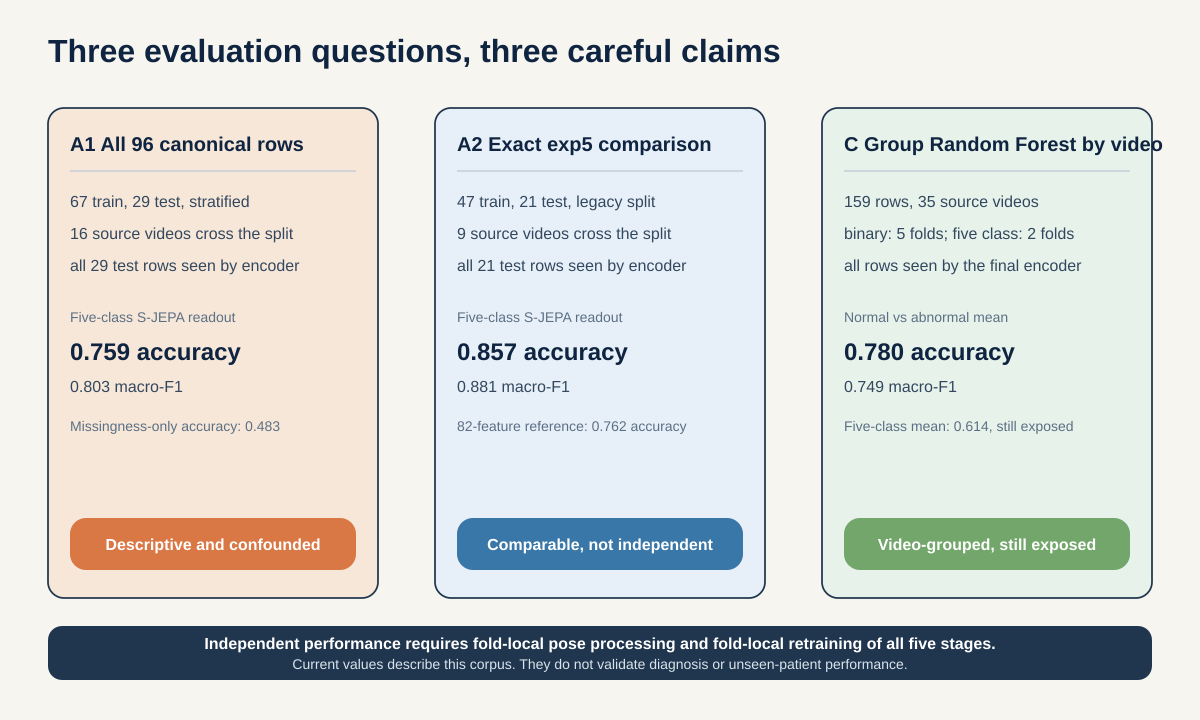

In [2]:
show_tutorial_svg("08_evaluation_protocol.svg")


## Step 2 of 16: restate the shared definitions and the exp5 row order

**What we are about to do.** Run seven definition cells, six of which are deliberate copies of notebook 04's so this notebook stands alone, plus one that is unique to the capstone.

The copied definitions: the 33 landmark names and the 12-index target whitelist; the locked cohort census; the synthetic smoke fixtures, which are code-path tests with no pathophysiological meaning; the preprocessing chain; the encoder, predictor, and EMA-teacher model classes; and the canonical and augmented pose loaders. The augmented loader applies the same recorded selection contract as notebook 04: `augmented_pose_extraction_report.csv` plus a coverage threshold of 0.45, which accepts 63 of 64 audited candidates.

**The cell that is unique to this notebook: `EXP5_ORDER`.** It is the literal list of the 68 sequence IDs that the earlier exp5 experiment used, **in its original order**, and `exp5_exact_split` reproduces exp5's split by seeding the legacy global NumPy random state and permuting that order.

**Why hard-code 68 IDs in a fixed order instead of just re-splitting.** Because a comparison against a saved baseline is only meaningful if the rows on each side are the same rows. The legacy `np.random.seed(42)` plus `np.random.permutation` is order-dependent, so reproducing exp5's exact 47/21 partition requires reproducing its exact input order. Using a modern `default_rng` here, or sorting the IDs, would produce a different test set and silently turn a like-for-like comparison into an incomparable one. The assertion `len(EXP5_ORDER) == 68` guards the list against edits.

**What we may conclude.** Nothing empirical. But note already that 68 of the 96 canonical sequences are exp5 rows, which is why Lane A2 covers a subset and Lane A1 covers everything.


In [3]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


In [4]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [5]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [6]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [7]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


In [8]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored_condition = str(data["condition"].item())
            if stored_condition != condition:
                raise ValueError(
                    f"Pose condition {stored_condition} does not match folder {condition}"
                )
            if len(data["frame_numbers"]) != len(sequence):
                raise ValueError(f"Frame and pose lengths differ in {path}")
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "extraction_version": str(data["extraction_version"].item()),
                "pose_model_sha256": str(data["pose_model_sha256"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, smoke_per_condition=10, frames=64):
    if MODE == "smoke":
        records = synthetic_corpus(
            conditions=conditions,
            n_per_condition=smoke_per_condition,
            frames=frames,
        )
        print(f"Explicit smoke corpus: {len(records)} synthetic sequences")
        return records
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [condition for condition in conditions if counts.get(condition, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. "
            "Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    """Load the self-annotated augmentation-normal cohort as a separate pool.

    These sequences live under a distinct pose folder written by
    notes/extract_augmented_poses.py. Their bounding boxes are auto-detected
    from MediaPipe Pose (bbox_source == "mediapipe_pose_auto"), not curated
    GAVD annotations, so they are always kept apart from the locked 96/18
    canonical corpus and only ever join an additive Lane C. Every canonical
    npz key is still validated; the extra provenance keys (cohort, clip_id,
    bbox_source) are tolerated.
    """
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    if not AUGMENTED_REPORT.is_file():
        raise FileNotFoundError(
            f"Missing augmentation selection contract: {AUGMENTED_REPORT}"
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    required_report = {"sequence_id", "status", "neuro_observed"}
    missing_report = required_report.difference(report.columns)
    if missing_report:
        raise ValueError(
            f"Augmentation report missing {sorted(missing_report)}"
        )
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce")
        >= MIN_AUGMENTED_NEURO_OBSERVED
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        required = {
            "sequence", "sequence_id", "video_id", "condition",
            "frame_numbers", "crop_bounds", "fps", "source_csv",
            "source_video", "pose_model", "pose_model_sha256",
            "extraction_version",
        }
        missing = required.difference(data.files)
        if missing:
            raise ValueError(
                f"Stale augmented pose cache {path} is missing {sorted(missing)}. "
                "Re-extract it with notes/extract_augmented_poses.py."
            )
        sequence = data["sequence"].astype(np.float32)
        if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
            raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
        if str(data["condition"].item()) != "normal":
            raise ValueError(
                f"Augmentation cohort must be normal; {path} is "
                f"{data['condition'].item()}"
            )
        if len(data["frame_numbers"]) != len(sequence):
            raise ValueError(f"Frame and pose lengths differ in {path}")
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "extraction_version": str(data["extraction_version"].item()),
            "pose_model_sha256": str(data["pose_model_sha256"].item()),
            "cohort": (
                str(data["cohort"].item())
                if "cohort" in data.files
                else "augmented_normal"
            ),
            "bbox_source": (
                str(data["bbox_source"].item())
                if "bbox_source" in data.files
                else "mediapipe_pose_auto"
            ),
            "sequence": sequence,
            "path": str(path),
        })
    return records


In [9]:
EXP5_ORDER = [
    "cljvvsucg00043n6l4evgn7q4", "cljr5jk0h000n3n6la34mkdfz",
    "cljo8eumx00683n6le2s7myd4", "cljr5fc5d000b3n6lkvc71zyl",
    "cljr5iki0000j3n6lwi8z5nh6", "cljo8cyv500603n6lyl148tmg",
    "cljo8g74m006g3n6l6kuxy9cf", "cljo8hcfv006k3n6lgrx0fcpx",
    "cljo8fdke006c3n6lr8bzjjgi", "cljo8c0sw005w3n6l9ulr2eg2",
    "cljo8e32t00643n6l37ncjeic", "cljr5hwxc000f3n6lof5w9tyt",
    "cljarhldg00d13n6l7utw0lqn", "cljo83yl800513n6lfglf5jn8",
    "cljawdoej000d3n6ll5ysj34f", "cljarmcm700dh3n6lxw24hxgx",
    "cljaxabfg003a3n6l95mrlcry", "cljarj6rf00d53n6ljtivf4q7",
    "cljarlbch00dd3n6l9jaubrxq", "cljarp08600dt3n6lxa7sysiv",
    "cljarpts600dx3n6l98zqf6yn", "cljaroguw00dp3n6lhfddiadu",
    "cljargosy00cx3n6lm6atozrz", "cljarn9oy00dl3n6l8pg9exfg",
    "cljarqtuz00e13n6lrnox6mfs", "cljaxbq22003i3n6lmzka93uq",
    "cljarkax200d93n6lukx52g1t", "cljax9d2p00363n6lx043s1m7",
    "cljaxb5y2003e3n6lj1j9qvav", "cljo84jju00553n6lmgm4dqtb",
    "cljawd01m00093n6l4kx9020l", "cljawb5nf00043n6l38chxsod",
    "cljnz7jnj000w3n6lku3pfvtm", "cljnz6vg1000s3n6lxxknbe72",
    "cljnz3l34000c3n6ldapq560j", "cljnz5sb1000o3n6lntosswwz",
    "cljan9b4p00043n6ligceanyp", "cljanb45y00083n6lmh1qhydd",
    "cljnyzwbo00043n6lugyldlhu", "cljnz4y5a000k3n6lkv4b1rjn",
    "cljnz4e8u000g3n6l1luikppo", "cljo340cm002a3n6low42ugvh",
    "cljo32xnz00223n6lvxzyif3y", "cljo33m8400263n6l4xxsl6ku",
    "cljo2y1f7001e3n6lt1wgacw6", "cljo3b2dy002l3n6l270vpzp8",
    "cljo2yqzp001i3n6lg75p7wtq", "cljo39ok9002h3n6ldr0w5sey",
    "cljo30lnz001q3n6lopfty7q5", "cljo2wwu7001a3n6ljmqm39l6",
    "cljo2zn41001m3n6lhbvww48i", "cljo32ik2001y3n6lmmnu0sgo",
    "cljo32213001u3n6lel97up5f", "cljar9bqo00c43n6l2u5zmlru",
    "cljarbn1y00cg3n6l1u4i0d5l", "cljardvzg00cs3n6loetskba6",
    "cljas71p600fv3n6lk1rzl7y5", "cljas134500f73n6lkfbjfayp",
    "cljarcfa700ck3n6lfww83ig1", "cljar9t8o00c83n6ltculhoct",
    "cljas1yfs00fb3n6lna38ui6i", "cljarar9t00cc3n6lqhi9udoc",
    "cljas5esv00fn3n6lewd5xqdl", "cljas4dqj00fj3n6ldw6wiwpy",
    "cljar878f00c03n6ly2v2ay88", "cljas04fw00f33n6lm5cvx9g6",
    "cljas2sou00ff3n6lasppj8h2", "cljarcy3g00co3n6lzsn1x034",
]


def exp5_exact_split(order, train_portion=0.70):
    """Reproduce the original notebook's legacy NumPy permutation."""
    np.random.seed(42)
    permutation = np.random.permutation(len(order))
    split_index = int(train_portion * len(order))
    train_ids = [order[index] for index in permutation[:split_index]]
    test_ids = [order[index] for index in permutation[split_index:]]
    return train_ids, test_ids


assert len(EXP5_ORDER) == 68


## Step 3 of 16: frame the capstone question

**What we are about to do.** State precisely what is being asked, so that the scores below cannot drift into answering a question nobody tested.

**The question.** What structure can a frozen final curriculum encoder expose through simple Random Forest readouts, and how much of that structure may come from detector missingness or source-video identity rather than gait?

**Why the framing changed since notebook 04's Stage 0.** This is no longer a normal-only self-supervised probe. Stage 0 was normal-only and label-free, but Stages 1 through 4 used condition-balanced replay **plus** a label-aware group loss. The classifier still sees one vector per sequence, but in the default full-corpus curriculum its held-out rows were already seen by representation training, **and their labels were part of the training objective**. That is a strictly stronger form of exposure than ordinary transduction: the encoder was not merely shown these sequences, it was rewarded for arranging them by their labels.

**Why a shallow Random Forest and not something stronger.** Because the point is to characterize the representation, not to maximize a score. A depth-limited forest on 384 frozen features tells you whether the label structure is readily available; a large fine-tuned model would blur the question of what the encoder had already organized.

**What we may conclude from this framing.** That the right way to read every number below is as an upper bound on descriptive recoverability inside an already-seen corpus.

**What we may not conclude.** That any of it is clinical validation, or that any of it says anything about an unseen video.


## Step 4 of 16: load the frozen encoder and the canonical corpus

**What we are about to do.** Select the final checkpoint, verify it, rebuild the model in evaluation mode, load all 96 canonical sequences, assert the exact cohort census, and gate on landmark coverage.

**Why the verification is this strict.** Only the EMA target encoder produces the readout features, and it must be the right one. The cell refuses to continue unless the checkpoint mode matches, the mask list is the 12-keypoint mapping whitelist, the curriculum is marked complete, the stage order is exactly `normal, parkinsons, stroke, myopathic, cerebralpalsy`, and the cohort agrees with `SJEPA_INCLUDE_AUGMENTED_NORMAL`. The notebook never silently substitutes a different cohort. The view encoder, predictor, and VICReg projector stay in the checkpoint for lineage and reproducibility even though only the target encoder is used here.

**Why assert the census rather than just count.** Two dictionaries are checked, not one: `expected_sequences` fixes the per-condition row counts at normal 12, Parkinson's 9, stroke 12, myopathic 47, cerebral palsy 16, and `expected_videos` fixes the per-condition **source-video** counts at normal 1, Parkinson's 2, stroke 3, myopathic 10, cerebral palsy 2. The second one is the important one, and it is why Lane B is blocked later: with a single normal video there is no way to hold a normal video out while keeping normal on both sides of a fold. Asserting the video census up front means that constraint is discovered here, in the data contract, rather than being rationalized after a fold fails.

**What to look at in the output.** The encoder filename and `augmented normal in checkpoint: True`. Then `Real pose corpus: 96 sequences`, the coverage table, and the class census. In the coverage table, note that stroke has the worst minimum at 0.578 against a mean of 0.943, so stroke is the condition whose apparent signal most needs the missingness control in Step 5. Finally, `Augmentation-normal cohort: 63 sequences across 17 source videos (mean neurologic observed 0.97)`, loaded into **separate parallel arrays**.

**Why the augmented rows are kept in separate arrays.** So that every locked lane keeps its exact census: 96 rows over 18 videos, a 47/21 exp5 split, and a shared-video count of 9. Only Lane C, much later, pools the canonical and augmented rows. If the augmented rows were concatenated here, every lane above would silently change and no comparison with the saved baselines would hold.

**What we may conclude.** That the frozen encoder is the intended one and the corpus is the locked one.

**What we may not conclude.** Anything about performance. Note also that the two `UserWarning` lines about `enable_nested_tensor` are a PyTorch note about `norm_first` layers and are harmless.


In [10]:
# The frozen encoder that produces every downstream embedding. When the
# augmentation cohort is enabled we require notebook 04's augmentation-broadened
# final curriculum encoder. The augmented variant broadens normal Stage 0,
# but both variants still see all condition rows during progressive fine-tuning. Either way the checkpoint
# choice is the ONLY thing the flag changes here -- the canonical corpus,
# census asserts, and coverage gate below are untouched.
explicit_checkpoint = os.getenv("SJEPA_CLASSIFIER_CHECKPOINT", "").strip()
if explicit_checkpoint:
    checkpoint_path = Path(explicit_checkpoint).expanduser()
    if not checkpoint_path.is_absolute():
        checkpoint_path = ARTIFACT_DIR / checkpoint_path
    checkpoint_source = "SJEPA_CLASSIFIER_CHECKPOINT"
else:
    checkpoint_path = (
        AUGMENTED_CHECKPOINT if INCLUDE_AUGMENTED_NORMAL else CANONICAL_CHECKPOINT
    )
    checkpoint_source = "SJEPA_INCLUDE_AUGMENTED_NORMAL"
if not checkpoint_path.is_file():
    available = sorted(path.name for path in ARTIFACT_DIR.glob("sjepa_curriculum_final*.pt"))
    raise FileNotFoundError(
        f"Expected final checkpoint {checkpoint_path} (selected by {checkpoint_source}). "
        f"Available final checkpoints: {available or 'none'}. "
        f"Run every stage of notebook 04 in {MODE} mode with the same "
        "SJEPA_INCLUDE_AUGMENTED_NORMAL setting, or set "
        "SJEPA_CLASSIFIER_CHECKPOINT explicitly."
    )
checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)
if checkpoint["mode"] != MODE:
    raise ValueError("Checkpoint mode does not match this notebook")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint used a different mask keypoint set")
expected_curriculum_conditions = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed five-stage curriculum")
if checkpoint.get("conditions_seen") != expected_curriculum_conditions:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
checkpoint_has_augmented_normal = "augmented_normal" in checkpoint.get("cohorts", [])
if not explicit_checkpoint and checkpoint_has_augmented_normal != INCLUDE_AUGMENTED_NORMAL:
    raise ValueError(
        "Checkpoint cohort does not match SJEPA_INCLUDE_AUGMENTED_NORMAL; "
        "rerun notebook 04 with the current setting or use an explicit checkpoint."
    )
print(f"Using final encoder: {checkpoint_path.name}")
print("checkpoint selection:", checkpoint_source)
print("augmented normal in checkpoint:", checkpoint_has_augmented_normal)
config = checkpoint["config"]
model = SJEPAGait(**config)
model.load_state_dict(checkpoint["model_state"])
model.eval()
FRAMES = config["frames"]

records = load_records_for_mode(
    conditions=CONDITIONS,
    smoke_per_condition=10,
    frames=FRAMES,
)
prepared = [
    prepare_sequence(record["sequence"], frames=FRAMES)
    for record in records
]
all_xyz = np.stack([item[0] for item in prepared])
all_valid = np.stack([item[1] for item in prepared])
sequence_ids = np.asarray([record["sequence_id"] for record in records])
video_ids = np.asarray([record["video_id"] for record in records])
labels = np.asarray([record["condition"] for record in records])
if len(set(sequence_ids.tolist())) != len(sequence_ids):
    raise ValueError("Cached pose sequence IDs must be unique")
if MODE == "real":
    expected_sequences = {
        "cerebralpalsy": 16,
        "myopathic": 47,
        "normal": 12,
        "parkinsons": 9,
        "stroke": 12,
    }
    expected_videos = {
        "cerebralpalsy": 2,
        "myopathic": 10,
        "normal": 1,
        "parkinsons": 2,
        "stroke": 3,
    }
    actual_sequences = pd.Series(labels).value_counts().to_dict()
    actual_videos = (
        pd.DataFrame({"condition": labels, "video_id": video_ids})
        .groupby("condition")["video_id"]
        .nunique()
        .to_dict()
    )
    if actual_sequences != expected_sequences:
        raise ValueError(
            f"Real capstone requires all 96 poses: {actual_sequences}"
        )
    if actual_videos != expected_videos:
        raise ValueError(
            f"Unexpected 18-video census: {actual_videos}"
        )
min_coverage = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
coverage_report = pd.DataFrame({
    "condition": labels,
    "sequence_id": sequence_ids,
    "video_id": video_ids,
    "neurologic_observed_fraction": all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2)),
})
display(coverage_report.groupby("condition")["neurologic_observed_fraction"].agg(["min", "mean"]))
if (coverage_report["neurologic_observed_fraction"] < min_coverage).any():
    raise ValueError("At least one sequence fails the neurologic coverage threshold")
coverage_report.to_csv(
    ARTIFACT_DIR / "classifier_pose_coverage.csv", index=False
)
display(pd.crosstab(labels, columns="sequences"))

# ---------------------------------------------------------------------------
# Augmentation-normal cohort (opt-in): loaded into SEPARATE parallel arrays.
# The canonical arrays above stay canonical-only, so every locked lane keeps
# its exact 96/18 census, 47/21 split, and shared==9 leakage count. The
# augmentation cohort only feeds the additive Lane C further down.
# ---------------------------------------------------------------------------
aug_records = augmented_normal_records() if INCLUDE_AUGMENTED_NORMAL else []
if aug_records:
    aug_prepared = [
        prepare_sequence(record["sequence"], frames=FRAMES)
        for record in aug_records
    ]
    aug_xyz = np.stack([item[0] for item in aug_prepared])
    aug_valid = np.stack([item[1] for item in aug_prepared])
    aug_sequence_ids = np.asarray([r["sequence_id"] for r in aug_records])
    aug_video_ids = np.asarray([r["video_id"] for r in aug_records])
    aug_labels = np.asarray([r["condition"] for r in aug_records])
    if set(aug_sequence_ids.tolist()) & set(sequence_ids.tolist()):
        raise ValueError(
            "Augmentation sequence_ids collide with canonical ids; they must "
            "be disjoint (aug-* prefix)."
        )
    aug_coverage = aug_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
    print(
        f"Augmentation-normal cohort: {len(aug_records)} sequences across "
        f"{len(set(aug_video_ids.tolist()))} source videos "
        f"(mean neurologic observed {aug_coverage.mean():.2f})."
    )
    pd.DataFrame({
        "sequence_id": aug_sequence_ids,
        "video_id": aug_video_ids,
        "cohort": [r["cohort"] for r in aug_records],
        "bbox_source": [r["bbox_source"] for r in aug_records],
        "neurologic_observed_fraction": aug_coverage,
    }).to_csv(
        ARTIFACT_DIR / "augmented_normal_pose_coverage.csv", index=False
    )
else:
    aug_xyz = np.empty((0, FRAMES, 33, 3), dtype=np.float32)
    aug_valid = np.empty((0, FRAMES, 33), dtype=bool)
    aug_sequence_ids = np.empty((0,), dtype=object)
    aug_video_ids = np.empty((0,), dtype=object)
    aug_labels = np.empty((0,), dtype=object)


Using final encoder: sjepa_curriculum_final_augmented.pt
checkpoint selection: SJEPA_INCLUDE_AUGMENTED_NORMAL
augmented normal in checkpoint: True
Real pose corpus: 96 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_86472/3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_86472/3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


,min,mean
condition,,
cerebralpalsy,0.980469,0.998291
myopathic,0.951823,0.993628
normal,0.925781,0.992296
parkinsons,0.846354,0.971644
stroke,0.578125,0.942600


col_0,sequences
row_0,
cerebralpalsy,16
myopathic,47
normal,12
parkinsons,9
stroke,12


Augmentation-normal cohort: 63 sequences across 17 source videos (mean neurologic observed 0.97).


## Step 5 of 16: build the missingness-only shortcut floor

**What we are about to do.** Build one feature vector per sequence from the pose **validity mask alone**, save it, and later fit the identical Random Forest on it using the identical split indices.

**What escape route this control closes, before you read its number.** Invalid landmarks remain zero sentinels inside the encoders so the timeline and tensor shape stay fixed. Validity-masked pooling stops those zero tokens from contributing directly to the pooled statistics, but **neighbouring Transformer tokens can still encode the detector-failure pattern**. If different conditions were filmed in ways that make MediaPipe fail differently, then a classifier could read the condition off the failure pattern without ever looking at how the person moved. That would be a shortcut, and no amount of accuracy would make it a gait result.

**What the missingness-only Random Forest actually is.** One feature vector per sequence, from the validity mask only:

- the per-joint observed fraction, how often each of the 33 landmarks cleared the visibility threshold across the 64 frames, which is `all_valid.mean(axis=1)`;
- concatenated with the per-frame observed fraction, how many of the 33 landmarks were valid in each frame, which is `all_valid.mean(axis=2)`.

That is 33 + 64 = **97 pose-visibility features and zero geometry**. The classifier can see where and when the detector failed and nothing about how the person moved. Fitting the same `make_rf()` pipeline on those 97 columns with the same split gives the **shortcut floor**: the score reachable purely from detector-failure patterns.

**How to read the comparison.** A missingness-only score at or above the latent score would mean that the pose detector, source video, crop quality, or occlusion pattern, rather than gait geometry, is carrying the labels. It would not prove that the latent classifier uses the shortcut, but it would make a gait-only interpretation unsafe. The S-JEPA embeddings must clear this floor for the result to be about walking at all.

**What the numbers turn out to be.** In the current real run the shortcut floor reaches **0.483** accuracy on the all-96 split, which is close to the 0.490 full-corpus majority reference, and **0.286** on the exact exp5 split. Both are well below the latent readouts reported in Steps 8 and 9, so missingness does not explain the separation. It may still contribute to individual predictions.

**What to look at in this cell's own output.** Only the per-condition coverage summary, now with a `max` column. The classifier comparison itself happens inside the lane cells, where the split indices live.


In [11]:
missingness_features = np.concatenate(
    [
        all_valid.mean(axis=1),
        all_valid.mean(axis=2),
    ],
    axis=1,
).astype(np.float32)
missingness_columns = [
    *[f"joint_valid_fraction_{joint:02d}" for joint in range(33)],
    *[f"frame_valid_fraction_{frame:02d}" for frame in range(FRAMES)],
]
missingness_table = pd.DataFrame(
    missingness_features, columns=missingness_columns
)
missingness_table.insert(0, "video_id", video_ids)
missingness_table.insert(0, "sequence_id", sequence_ids)
missingness_table.insert(0, "condition", labels)
missingness_table.to_csv(
    ARTIFACT_DIR / "pose_missingness_features.csv", index=False
)
display(
    coverage_report.groupby("condition")[
        "neurologic_observed_fraction"
    ].agg(["min", "mean", "max"])
)


,min,mean,max
condition,,,
cerebralpalsy,0.980469,0.998291,1.0
myopathic,0.951823,0.993628,1.0
normal,0.925781,0.992296,1.0
parkinsons,0.846354,0.971644,1.0
stroke,0.578125,0.942600,1.0


## Step 6 of 16: freeze and pool one vector per sequence

**What we are about to do.** Run every sequence through the frozen target encoder and pool its tokens into one fixed-length vector, then save the matrix to Parquet with the checkpoint fingerprint attached.

**Why the pooling contract is restated rather than assumed.** It is identical to notebook 05's: validity-masked global mean and standard deviation, followed by validity-masked mean and standard deviation over the 12 authorized landmarks. A patch contributes only when all four of its source frames are valid for that joint. It is documented because the S-JEPA paper does not specify exact downstream pooling, so this is our design choice, and a different choice would move every number in the notebook. Keeping it byte-identical to notebook 05 is what makes the geometry there and the scores here statements about the same vectors.

**Why the fingerprint is written into the Parquet file.** So that a saved embedding matrix can never be silently paired with the wrong encoder. The column records `ea59fea055f0230b...`, the same fingerprint notebooks 04 and 05 reported.

**What to look at in the output.** `embedding matrix: (96, 384)`, which is 96 sequences by four blocks of the 96-dimensional embedding, and `augmentation embedding matrix: (63, 384)` in a separate file. The assertions confirm both matrices are finite and have matching widths.

**What we may conclude.** That every sequence has a finite, fixed-length, provenance-tagged feature vector, and that the canonical and augmented matrices remain separate until Lane C.


In [12]:
def masked_mean_std(tokens, mask):
    weights = torch.as_tensor(
        mask, dtype=tokens.dtype, device=tokens.device
    ).unsqueeze(-1)
    denominator = weights.sum(dim=1).clamp_min(1.0)
    mean = (tokens * weights).sum(dim=1) / denominator
    variance = (
        (tokens - mean[:, None, :]).square() * weights
    ).sum(dim=1) / denominator
    return mean, variance.clamp_min(0.0).sqrt()


@torch.no_grad()
def pooled_embeddings(model, arrays, validity, batch_size=8):
    vectors = []
    segments = model.target_encoder.segments
    segment_length = model.target_encoder.segment_length
    dimension = model.target_encoder.embed_dim
    if len(arrays) == 0:
        return np.empty((0, 4 * dimension), dtype=np.float32)
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(
            arrays[start:start + batch_size],
            dtype=torch.float32,
        )
        tokens = model.target_encoder(batch).reshape(
            len(batch), segments, 33, dimension
        )
        valid_patch = np.asarray(
            validity[start:start + batch_size], dtype=bool
        ).reshape(
            len(batch), segments, segment_length, 33
        ).all(axis=2)
        global_tokens = tokens.reshape(len(batch), -1, dimension)
        neuro_tokens = tokens[:, :, MASK_KEYPOINTS].reshape(
            len(batch), -1, dimension
        )
        global_mean, global_std = masked_mean_std(
            global_tokens, valid_patch.reshape(len(batch), -1)
        )
        neuro_mean, neuro_std = masked_mean_std(
            neuro_tokens,
            valid_patch[:, :, MASK_KEYPOINTS].reshape(len(batch), -1),
        )
        vectors.append(torch.cat([
            global_mean,
            global_std,
            neuro_mean,
            neuro_std,
        ], dim=1).cpu())
    return torch.cat(vectors).numpy()


embeddings = pooled_embeddings(model, all_xyz, all_valid)
assert embeddings.shape[0] == len(sequence_ids)
assert np.isfinite(embeddings).all()
feature_columns = [
    f"latent_{index:04d}" for index in range(embeddings.shape[1])
]
embedding_table = pd.DataFrame(embeddings, columns=feature_columns)
embedding_table.insert(0, "video_id", video_ids)
embedding_table.insert(0, "sequence_id", sequence_ids)
embedding_table.insert(0, "condition", labels)
embedding_table.insert(0, "mode", MODE)
embedding_table.insert(
    0, "checkpoint_fingerprint", checkpoint["dataset_fingerprint"]
)
embedding_path = ARTIFACT_DIR / "sequence_embeddings.parquet"
embedding_table.to_parquet(embedding_path, index=False)
print("embedding matrix:", embeddings.shape)
print("saved:", embedding_path)

# Embed the augmentation-normal cohort with the same frozen encoder into a
# separate matrix. Empty (0, 4*D) when the cohort is disabled, so nothing
# downstream changes unless Lane C explicitly consumes it.
aug_embeddings = pooled_embeddings(model, aug_xyz, aug_valid)
assert aug_embeddings.shape[0] == len(aug_sequence_ids)
if len(aug_embeddings):
    assert aug_embeddings.shape[1] == embeddings.shape[1]
    assert np.isfinite(aug_embeddings).all()
    aug_embedding_table = pd.DataFrame(aug_embeddings, columns=feature_columns)
    aug_embedding_table.insert(0, "video_id", aug_video_ids)
    aug_embedding_table.insert(0, "sequence_id", aug_sequence_ids)
    aug_embedding_table.insert(0, "condition", aug_labels)
    aug_embedding_table.insert(0, "cohort", "augmented_normal")
    aug_embedding_table.insert(0, "mode", MODE)
    aug_embedding_table.insert(
        0, "checkpoint_fingerprint", checkpoint["dataset_fingerprint"]
    )
    aug_embedding_path = ARTIFACT_DIR / "augmented_normal_embeddings.parquet"
    aug_embedding_table.to_parquet(aug_embedding_path, index=False)
    print("augmentation embedding matrix:", aug_embeddings.shape)
    print("saved:", aug_embedding_path)


embedding matrix: (96, 384)
saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/sequence_embeddings.parquet
augmentation embedding matrix: (63, 384)
saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/augmented_normal_embeddings.parquet


## Step 7 of 16: fix one Random Forest specification so the lanes are comparable

**What we are about to do.** Define `make_rf()` once, plus a single scoring function, and use them everywhere.

**Why one specification for every lane.** If each lane tuned its own classifier, a difference between lanes would be uninterpretable: it could be the split, or it could be the hyperparameters. Fixing the pipeline means every difference below is attributable to the **split and the features**, which is the only thing we are trying to measure. The same pipeline is used for the latent lanes, the missingness-only controls, the one-versus-normal readouts, and Lane C.

**The specification, matching exp5.** StandardScaler, then a Random Forest with 100 trees, maximum depth 5, square-root feature sampling, bootstrap, balanced class weights, and `random_state=42`. Trees do not normally need feature scaling, but retaining the scaler keeps this pipeline aligned with the exp5 comparison rather than introducing one more difference into it.

**What `class_weight="balanced"` does, and what it does not.** It gives rare classes more influence during fitting so the 47 myopathic rows do not dominate through frequency alone. It does **not** repair leakage and it does not create new independent videos.

**The three scores, and why all three are reported.** `accuracy` is the fraction of test rows correct and can be flattered by the largest class. `balanced_accuracy` averages the five per-condition recalls so each condition counts equally regardless of row count. `macro_f1` averages a per-condition F1, which combines precision with recall, so it penalizes both false alarms and misses. On an imbalanced five-class problem the three can disagree, and the disagreement is informative.

**A note on how the exp5 split differs.** exp5's split was **not stratified**. It used the legacy global NumPy random state and permuted the native 68-item feature order, so `default_rng` would produce a different test set. That is why Step 2 hard-codes the row order.

**What we may conclude.** Nothing yet. This cell only removes classifier configuration as a source of between-lane difference.


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

CLASS_ORDER = [
    "cerebralpalsy", "myopathic", "normal", "parkinsons", "stroke"
]


def make_rf():
    return Pipeline([
        ("scale", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ])


def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
    }


## Step 8 of 16, Lane A1: all-96 stratified, step by step

**What we are about to do.** Split all 96 canonical sequence rows 70/30 with class stratification, fit the readout on the training rows, score the held-out rows, then fit the missingness-only control on the same indices and intersect the train and test video sets.

**What the saved split name tells you.** It is `all_96_stratified_video_confounded`, and each part is load-bearing:

- **all-96**: all 96 canonical GAVD sequence rows enter the split. It does **not** mean all 96 train the Random Forest: 67 train it and 29 test it.
- **stratified**: the split preserves each condition's fraction on both sides instead of drawing 67 rows without regard to class.
- **video-confounded**: sequences, not source videos, are split. Different excerpts from one YouTube upload can therefore appear on both sides. The name carries the flaw so that no one can quote the lane without it.

### Background: what is one row?

A row is one annotated walking **sequence**, not one frame, one source video, or necessarily one independent person. Notebook 02 turns its frame span into a fixed pose tensor. Notebook 04's final target encoder maps that tensor to one pooled S-JEPA embedding. Here `embeddings[i]` is the feature vector and `labels[i]` is the folder condition annotation for sequence `i`. The classifier sees embeddings, not raw pixels.

The canonical real-data census is imbalanced:

|Condition annotation|All rows|Train rows|Test rows|
|---|---:|---:|---:|
|Cerebral palsy|16|11|5|
|Myopathic|47|33|14|
|Normal|12|8|4|
|Parkinson's|9|6|3|
|Stroke|12|9|3|
|**Total**|**96**|**67**|**29**|

These are dataset annotations, not diagnoses made or independently verified by this tutorial.

### Step 8a: create sequence indices

`all_index = np.arange(len(labels))` creates the integers 0 through 95. Splitting indices rather than the embedding matrix itself is what keeps each row's embedding, label, sequence ID, and video ID aligned; the leakage audit in Step 10 depends on that alignment holding.

### Step 8b: make a reproducible 70/30 stratified split

`train_test_split(..., train_size=0.70, stratify=labels, random_state=42)` assigns about 70 percent of every class to training. If class `c` has `n_c` rows, stratification allocates roughly `0.70 * n_c` to training while satisfying integer totals, and scikit-learn resolves the rounding jointly to produce exactly the table above.

**Why stratify?** A plain random draw could put too few examples of the nine-row Parkinson's class into the test set, and then a score could change mostly because the test class mixture changed rather than because the model changed. Stratification makes the five-class comparison more stable and guarantees every condition appears on both sides. `random_state=42` makes the assignment repeatable; it does not make 42 statistically special.

**What stratification does not fix.** It solves **class-balance sampling** only. It does not prevent source-video overlap, subject overlap when subject identity is unknown, or prior encoder exposure. Class balancing and data independence are different problems, and only the first one is addressed here.

### Step 8c: fit the readout on 67 embeddings

`make_rf()` builds the fixed pipeline from Step 7. `StandardScaler` estimates its mean and standard deviation from the **67 training embeddings only** and applies that transformation to both subsets, which is the correct direction: fitting the scaler on all 96 would leak test-row statistics into the transform. Then only `embeddings[all_train_index]` and their labels fit the forest, and predictions are made for the 29 held-out rows.

### Step 8d: read three complementary scores

Use the definitions from Step 7, and read the classification report and confusion matrix alongside them rather than the headline alone. One aggregate number can hide a class that is never recognized, which is exactly what the per-class report exists to reveal.

### Step 8e: audit shortcuts and dependence in the same cell

The cell then fits the missingness-only Random Forest from Step 5 on the **identical indices**, giving the shortcut floor for this exact split, and intersects the train and test `video_id` sets. Both audits are computed here rather than later so that a reader cannot see the score without also seeing what it depends on.

### What this lane can and cannot answer

It answers a useful engineering question: **after training the final encoder, can a shallow classifier recover the five dataset labels from its embeddings across a fixed sequence-level partition?** It exercises all 96 canonical rows, produces comparable diagnostics, and would expose broken features or a collapsed representation.

It does **not** estimate performance on a new patient, a new camera, or an unseen YouTube video. The test rows are held out from the Random Forest but not from representation learning, and most source videos cross the split. The score is a **transductive, label-informed descriptive readout** and may be optimistic. Neither stratification nor balanced class weights change that. Lane A2 answers a legacy-comparison question, and Lane C moves toward video-disjoint evaluation while explaining why a fully independent estimate would still require retraining the entire encoder inside each outer training fold.


In [14]:
from sklearn.model_selection import train_test_split

all_index = np.arange(len(labels))
all_train_index, all_test_index = train_test_split(
    all_index,
    train_size=0.70,
    random_state=42,
    stratify=labels,
)
all_train_ids = sequence_ids[all_train_index].tolist()
all_test_ids = sequence_ids[all_test_index].tolist()
all_split_name = (
    "all_96_stratified_video_confounded"
    if MODE == "real"
    else "smoke_all_stratified"
)
all_sequence_model = make_rf()
all_sequence_model.fit(
    embeddings[all_train_index], labels[all_train_index]
)
all_sequence_prediction = all_sequence_model.predict(
    embeddings[all_test_index]
)
all_sequence_metrics = score_predictions(
    labels[all_test_index], all_sequence_prediction
)
all_sequence_report = pd.DataFrame(classification_report(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
all_shared_videos = sorted(
    set(video_ids[all_train_index]) & set(video_ids[all_test_index])
)
print(all_split_name, all_sequence_metrics)
print("shared train/test source videos:", all_shared_videos)
display(all_sequence_report)

all_missingness_model = make_rf()
all_missingness_model.fit(
    missingness_features[all_train_index], labels[all_train_index]
)
all_missingness_prediction = all_missingness_model.predict(
    missingness_features[all_test_index]
)
all_missingness_metrics = score_predictions(
    labels[all_test_index], all_missingness_prediction
)
print("missingness-only audit:", all_missingness_metrics)


all_96_stratified_video_confounded {'accuracy': 0.7586206896551724, 'balanced_accuracy': 0.8485714285714285, 'macro_f1': 0.8030909090909091}
shared train/test source videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8NlJgIySMG0'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('B5hrxKe2nP8'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('jzJIpY6vRLo'), np.str_('wRntYsztIEY')]


,precision,recall,f1-score,support
cerebralpalsy,0.500000,0.600000,0.545455,5.000000
myopathic,0.818182,0.642857,0.720000,14.000000
normal,1.000000,1.000000,1.000000,4.000000
parkinsons,1.000000,1.000000,1.000000,3.000000
stroke,0.600000,1.000000,0.750000,3.000000
accuracy,0.758621,0.758621,0.758621,0.758621
macro avg,0.783636,0.848571,0.803091,29.000000
weighted avg,0.784639,0.758621,0.760596,29.000000


missingness-only audit: {'accuracy': 0.4827586206896552, 'balanced_accuracy': 0.5066666666666666, 'macro_f1': 0.47727272727272724}


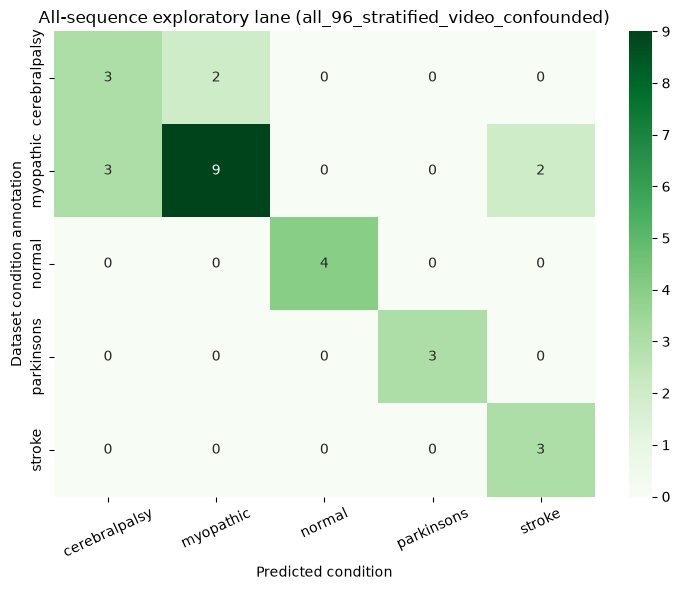

,sequence_id,video_id,true_condition,predicted_condition
4,cljr5wgkf001w3n6lwp1w3wlu,8PPLTf0fZsY,myopathic,cerebralpalsy
7,cljas1yfs00fb3n6lna38ui6i,DlPDuHBAP7A,cerebralpalsy,myopathic
9,cljas4dqj00fj3n6ldw6wiwpy,DlPDuHBAP7A,cerebralpalsy,myopathic
11,cljr5tz3c001k3n6lfc27vpnp,8PPLTf0fZsY,myopathic,stroke
12,cljr5unji001o3n6lapqpzkio,8PPLTf0fZsY,myopathic,cerebralpalsy
22,cljo84jju00553n6lmgm4dqtb,05oyBOE_0UE,myopathic,stroke
26,cljarhldg00d13n6l7utw0lqn,R8LRCiTvUz8,myopathic,cerebralpalsy


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

all_sequence_confusion = confusion_matrix(
    labels[all_test_index],
    all_sequence_prediction,
    labels=CLASS_ORDER,
)
all_figure, all_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    all_sequence_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=all_axis,
)
all_axis.set_title(f"All-sequence exploratory lane ({all_split_name})")
all_axis.set_xlabel("Predicted condition")
all_axis.set_ylabel("Dataset condition annotation")
all_axis.tick_params(axis="x", labelrotation=25)
all_figure.tight_layout()
all_figure.savefig(
    ARTIFACT_DIR / "all_sequences_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
all_error_table = pd.DataFrame({
    "sequence_id": sequence_ids[all_test_index],
    "video_id": video_ids[all_test_index],
    "true_condition": labels[all_test_index],
    "predicted_condition": all_sequence_prediction,
})
all_error_table = all_error_table[
    all_error_table["true_condition"]
    != all_error_table["predicted_condition"]
]
display(all_error_table)


### Reading the Lane A1 output

**The scores, from the executed output.** Accuracy **0.759**, balanced accuracy **0.849**, macro-F1 **0.803**, on 29 test rows.

**The controls, read first.** The missingness-only Random Forest on the same indices reached **0.483** accuracy, and the majority class among those 29 test rows is also **0.483**. So the latent readout clears the shortcut floor by about 0.276 accuracy. That gap is the actual content of this lane: the embeddings carry label information that pose-visibility patterns alone do not.

**The exposure, read second.** `shared train/test source videos` lists **16** videos, and the test side contains only 16 distinct videos in total, so **every single test video also appears in training**. Step 10 adds the other half of the disclosure: all 29 test rows were also seen by the encoder during label-aware representation training.

**The per-class report, read third, because the aggregates hide the shape.** Normal and Parkinson's are perfect on precision and recall. Stroke has recall 1.000 but precision 0.600, so the model over-predicts stroke. Myopathic, the largest class, has the **lowest recall at 0.643** despite precision of 0.818. Cerebral palsy is weakest overall at 0.500 precision and 0.600 recall.

This is why balanced accuracy of 0.849 is higher than accuracy of 0.759: the small classes are handled well and the big class is not, so equal-weighting the five recalls flatters the model relative to counting rows. Reading only balanced accuracy would overstate the result, and reading only accuracy would hide that normal and Parkinson's were solved.

**The error table confirms the pattern.** All seven mistakes are confined to three conditions: cerebral palsy predicted as myopathic twice, myopathic predicted as cerebral palsy three times, and myopathic predicted as stroke twice. Four of the seven errors come from just two source videos, `8PPLTf0fZsY` and `DlPDuHBAP7A`, which is a reminder that the effective sample size here is videos, not rows.

**What we may conclude.** On this fixed sequence partition, the frozen embeddings contain substantially more five-class label information than detector missingness or the majority class provides.

**What we may not conclude.** That 0.759 estimates performance anywhere. Every test video was in training, every test row was in representation training, and the encoder's objective included these labels. The number is a descriptive upper bound. Recall also from notebook 05 that the cosine silhouette of this same representation is 0.054, so this accuracy is **not** evidence of clean condition separation.


## Step 9 of 16, Lane A2: the exact exp5-compatible split

**What we are about to do.** Select the 68 exp5 sequence IDs, reproduce exp5's legacy 47/21 partition exactly, and fit the same pipeline plus the same missingness control on it.

**Why a second sequence-level lane at all.** Lane A1 already covers all 96 rows, so A2 adds no new data. It exists for exactly one purpose: **comparability**. The saved exp5 handcrafted result was computed on a specific 47/21 partition of a specific 68 rows, and a comparison against it is only like-for-like if those same rows sit on those same sides. The remaining 28 sequences stay in Lane A1.

**What the cell guards.** In real mode it refuses to continue unless all 96 cached sequences are present and every one of the 68 exp5 IDs resolves, then asserts that the split really is 47 and 21. Smoke mode substitutes a clearly labelled stratified demonstration, because synthetic IDs cannot reproduce exp5 and a smoke number must never be mistaken for the comparison.

**What to look at in the output.** The three scores, the missingness-only floor on the same indices, and the per-class report.

**What the output shows.** Accuracy **0.857**, balanced accuracy **0.891**, macro-F1 **0.881**, on 21 test rows. The missingness-only floor is **0.286**, and the majority class among those 21 rows is 0.333, so the latent readout clears the shortcut floor by about 0.571 accuracy. Per class: normal and Parkinson's again perfect; stroke recall 1.000 at precision 0.750; myopathic recall 0.857 at precision 0.750; cerebral palsy precision 1.000 but **recall only 0.600**, so two of five cerebral-palsy rows were missed. The only errors are one myopathic row predicted as stroke and two cerebral-palsy rows predicted as myopathic.

**What we may conclude.** This is the strongest descriptive score in the notebook, and it is comparable with the exp5 baseline on the same rows.

**What we may not conclude, and this is the important part.** **This split is video-confounded and encoder-exposed.** All 9 of its test videos also appear in training, all 21 test rows were seen during label-aware representation training, and the split is neither stratified nor group-aware. The fact that it scores higher than Lane A1's 0.759 on a smaller, non-stratified test set of 21 rows is not evidence of anything except that small test sets are noisy and this particular partition was favourable. A difference of 0.098 accuracy across 21 versus 29 rows is well inside what row-level partition luck can produce. Do not read A2 as an improvement on A1.


In [16]:
id_to_index = {
    sequence_id: index
    for index, sequence_id in enumerate(sequence_ids)
}
if MODE == "real":
    missing = [item for item in EXP5_ORDER if item not in id_to_index]
    if missing:
        raise FileNotFoundError(
            f"Missing {len(missing)} exp5 pose sequences. "
            "Extract the full curated set in notebook 02."
        )
    train_ids, test_ids = exp5_exact_split(EXP5_ORDER)
    train_index = np.asarray([id_to_index[item] for item in train_ids])
    test_index = np.asarray([id_to_index[item] for item in test_ids])
    split_name = "exp5_exact_video_confounded"
    assert len(train_index) == 47 and len(test_index) == 21
else:
    from sklearn.model_selection import train_test_split
    all_index = np.arange(len(labels))
    train_index, test_index = train_test_split(
        all_index,
        train_size=0.70,
        random_state=42,
        stratify=labels,
    )
    train_ids = sequence_ids[train_index].tolist()
    test_ids = sequence_ids[test_index].tolist()
    split_name = "smoke_stratified_not_exp5"

five_class_model = make_rf()
five_class_model.fit(embeddings[train_index], labels[train_index])
five_class_prediction = five_class_model.predict(embeddings[test_index])
five_class_metrics = score_predictions(
    labels[test_index], five_class_prediction
)
exp5_missingness_model = make_rf()
exp5_missingness_model.fit(
    missingness_features[train_index], labels[train_index]
)
exp5_missingness_prediction = exp5_missingness_model.predict(
    missingness_features[test_index]
)
exp5_missingness_metrics = score_predictions(
    labels[test_index], exp5_missingness_prediction
)
print(split_name, five_class_metrics)
print("missingness-only audit:", exp5_missingness_metrics)
five_class_report = pd.DataFrame(classification_report(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
    zero_division=0,
    output_dict=True,
)).T
display(five_class_report)


exp5_exact_video_confounded {'accuracy': 0.8571428571428571, 'balanced_accuracy': 0.8914285714285715, 'macro_f1': 0.8814285714285713}
missingness-only audit: {'accuracy': 0.2857142857142857, 'balanced_accuracy': 0.2704761904761904, 'macro_f1': 0.27714285714285714}


,precision,recall,f1-score,support
cerebralpalsy,1.000000,0.600000,0.750000,5.000000
myopathic,0.750000,0.857143,0.800000,7.000000
normal,1.000000,1.000000,1.000000,3.000000
parkinsons,1.000000,1.000000,1.000000,3.000000
stroke,0.750000,1.000000,0.857143,3.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.900000,0.891429,0.881429,21.000000
weighted avg,0.880952,0.857143,0.853401,21.000000


## Step 10 of 16: audit source-video overlap and encoder exposure

**What we are about to do.** For each sequence-level lane, count the training and test videos, count how many videos appear on both sides, and count how many test rows appear in the checkpoint's own list of representation-training sequence IDs.

**Why both counts, and why the second one is the stricter test.** A sequence-level split is not independent when train and test rows come from the same source upload, so the shared-video count is the first disclosure. But the encoder is the bigger problem. This audit therefore intersects every classifier test set with **all** sequence IDs used in the progressive representation curriculum, read directly out of `checkpoint["sequence_ids"]` rather than reconstructed. Because the later group loss used condition annotations, an overlap means both sample exposure **and** label-informed representation exposure.

**Why read it from the checkpoint.** Because the checkpoint is the record of what was actually trained on. Recomputing the training set from the current environment would report what we believe was trained on, which is a different and weaker claim.

**What to look at in the output.** The `shared_train_test_videos` column against `test_videos`, the `test_sequences_seen_in_representation_training` column against `test_sequences`, and the `representation_training_was_label_aware` flag.

**What the output shows.**

| Lane | train / test rows | train / test videos | shared videos | test rows seen by the encoder | label-aware |
|---|---|---|---:|---:|---|
| `all_96_stratified_video_confounded` | 67 / 29 | 18 / 16 | **16 of 16** | **29 of 29** | True |
| `exp5_exact_video_confounded` | 47 / 21 | 12 / 9 | **9 of 9** | **21 of 21** | True |

Read those two right-hand columns together. In both lanes, **every** test video is also a training video and **every** test row was already used to train the encoder, with its label in the objective from Stage 1 onward. There is no partially-exposed case here to argue about. The cell prints an explicit `TRANSDUCTIVE WARNING` on that basis, and the assertion `set(test_videos).issubset(train_videos)` makes the total overlap a checked property rather than an observation.

**What we may conclude.** That the exposure is complete, quantified, and recorded in `leakage_audit.csv` next to the scores.

**What we may not conclude.** That disclosure repairs anything. Reporting leakage precisely makes a score honest to read; it does not make it a generalization estimate. Steps 8 and 9 remain descriptive.


In [17]:
representation_training_ids = set(checkpoint["sequence_ids"])


def leakage_row(name, fit_index, held_out_index):
    fit_videos = set(video_ids[fit_index])
    held_out_videos = set(video_ids[held_out_index])
    overlap = sorted(fit_videos & held_out_videos)
    representation_overlap = sorted(
        set(sequence_ids[held_out_index]) & representation_training_ids
    )
    return {
        "mode": MODE,
        "split": name,
        "train_sequences": len(fit_index),
        "test_sequences": len(held_out_index),
        "train_videos": len(fit_videos),
        "test_videos": len(held_out_videos),
        "shared_train_test_videos": len(overlap),
        "test_sequences_seen_in_representation_training": len(representation_overlap),
        "representation_training_was_label_aware": bool(
            checkpoint.get("label_aware_after_stage0", False)
        ),
    }, overlap


all_leakage, all_shared_videos = leakage_row(
    all_split_name, all_train_index, all_test_index
)
exp5_leakage, shared_videos = leakage_row(
    split_name, train_index, test_index
)
leakage_audit = pd.DataFrame([all_leakage, exp5_leakage])
display(leakage_audit)
print("all-sequence shared videos:", all_shared_videos)
print("exp5-compatible shared videos:", shared_videos)
if leakage_audit["test_sequences_seen_in_representation_training"].gt(0).any():
    print(
        "TRANSDUCTIVE WARNING: classifier test rows were used by the staged encoder. "
        "Treat every score below as a within-corpus descriptive readout."
    )
if MODE == "real":
    train_videos = set(video_ids[train_index])
    test_videos = set(video_ids[test_index])
    assert len(shared_videos) == 9
    assert set(test_videos).issubset(train_videos)


,mode,split,train_sequences,test_sequences,train_videos,test_videos,shared_train_test_videos,test_sequences_seen_in_representation_training,representation_training_was_label_aware
0,real,all_96_stratified_video_confounded,67,29,18,16,16,29,True
1,real,exp5_exact_video_confounded,47,21,12,9,9,21,True


all-sequence shared videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('5qM6wxZ_dNs'), np.str_('7Ft1bUTzxkM'), np.str_('8NlJgIySMG0'), np.str_('8PPLTf0fZsY'), np.str_('8mTHlAIdea0'), np.str_('9qg-3smwLcs'), np.str_('B5hrxKe2nP8'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('jzJIpY6vRLo'), np.str_('wRntYsztIEY')]
exp5-compatible shared videos: [np.str_('05oyBOE_0UE'), np.str_('3KnFt8bH3tE'), np.str_('5gpoegYv1hs'), np.str_('8mTHlAIdea0'), np.str_('DlPDuHBAP7A'), np.str_('HDkWDe6FZDg'), np.str_('R8LRCiTvUz8'), np.str_('_Wn9oYGpRdM'), np.str_('wRntYsztIEY')]
TRANSDUCTIVE WARNING: classifier test rows were used by the staged encoder. Treat every score below as a within-corpus descriptive readout.


## Step 11 of 16: read the five-class confusion matrix

**What we are about to do.** Plot the Lane A2 confusion matrix with a fixed row and column order, and list every misclassified sequence with its source video.

**Why a fixed class order matters.** `CLASS_ORDER` is held constant at cerebral palsy, myopathic, normal, Parkinson's, stroke so that this matrix can be compared cell by cell with exp5's saved matrix in Step 14. A matrix with a different ordering looks similar and compares wrongly.

**Why look at the matrix when the per-class report is already printed.** The report gives per-class precision and recall but not **which** class the errors went to. Confusion structure is the interpretable part: errors concentrated in one off-diagonal pair suggest two categories that overlap in the representation, while errors scattered everywhere suggest the readout is weak overall.

**What to look at.** The off-diagonal cells, and then the error table's `video_id` column.

**What the output shows.** Three errors in total: one myopathic row predicted as stroke, and two cerebral-palsy rows predicted as myopathic. **Both cerebral-palsy errors come from the same source video, `DlPDuHBAP7A`.**

**What we may conclude.** The confusions are concentrated rather than diffuse, and they fall between categories with overlapping movement characteristics. That is consistent with notebook 05's geometry, where the closest condition centroids were only 0.026 apart.

**What we may not conclude.** Any clinical reading of which conditions "resemble" each other. With 5 cerebral-palsy test rows, 2 errors from a single video, and a total of 21 test rows, this matrix cannot distinguish a genuine category overlap from one hard video. The unit of evidence is the video, and here it is effectively one.


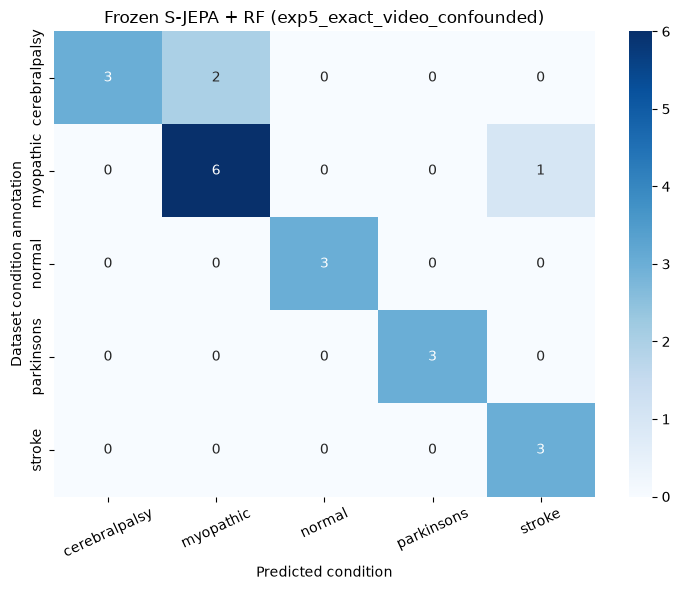

,sequence_id,video_id,true_condition,predicted_condition
0,cljo84jju00553n6lmgm4dqtb,05oyBOE_0UE,myopathic,stroke
6,cljas5esv00fn3n6lewd5xqdl,DlPDuHBAP7A,cerebralpalsy,myopathic
15,cljas134500f73n6lkfbjfayp,DlPDuHBAP7A,cerebralpalsy,myopathic


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

five_class_confusion = confusion_matrix(
    labels[test_index],
    five_class_prediction,
    labels=CLASS_ORDER,
)
confusion_figure, confusion_axis = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    five_class_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=confusion_axis,
)
confusion_axis.set_title(f"Frozen S-JEPA + RF ({split_name})")
confusion_axis.set_xlabel("Predicted condition")
confusion_axis.set_ylabel("Dataset condition annotation")
confusion_axis.tick_params(axis="x", labelrotation=25)
confusion_figure.tight_layout()
confusion_figure.savefig(
    ARTIFACT_DIR / "five_class_confusion_matrix.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
error_table = pd.DataFrame({
    "sequence_id": sequence_ids[test_index],
    "video_id": video_ids[test_index],
    "true_condition": labels[test_index],
    "predicted_condition": five_class_prediction,
})
error_table = error_table[
    error_table["true_condition"] != error_table["predicted_condition"]
]
display(error_table)


## Step 12 of 16: fit four one-versus-normal readouts

**What we are about to do.** For each non-normal condition, keep only that condition and normal, and fit a binary readout using the **same** Lane A1 train and test indices.

**Why the class filter is applied after the global split, not before.** If each binary task were split independently, each one could land on a favourable partition, and four separately-lucky splits would look like four successes. Filtering after the single global split means all four tasks inherit one partition, so their results are comparable with each other and with Lane A1. It also uses every available condition-folder row rather than selecting an easier subset for one condition.

**Why include ROC-AUC here but not in the five-class lanes.** ROC-AUC needs a single positive class and a probability score, which a binary task has and a five-class task does not without further choices. It is computed only when both classes are actually present in the test subset.

**What to look at in the output.** The accuracy column, and immediately next to it the `test_sequences` column. Read them together, always.

**What the output shows.** All four readouts return **1.000** on accuracy, balanced accuracy, macro-F1, and ROC-AUC. The test-set sizes are 7 sequences for Parkinson's versus normal, 7 for stroke, 18 for myopathic, and 9 for cerebral palsy.

**What we may conclude.** Nothing that a perfect score usually implies. Read this as a **separability check that came out saturated**, which means the task did not discriminate between hypotheses and so carries almost no information.

**What we may not conclude, stated bluntly.** These are not evidence of near-perfect detection. Four things make a perfect score here close to uninformative:

1. **The test sets are tiny.** With 7 test sequences, a single flip would move accuracy by 0.143, and the difference between a genuinely perfect model and a mediocre one is a couple of rows.
2. **Source videos overlap with training** in every one of the four tasks, inheriting Lane A1's total video overlap.
3. **The encoder saw every row and every label** during Stages 1 through 4.
4. **Normal comes from one source video.** A binary task against a single-video negative class can be won by recognizing that video.

A perfect score under those conditions is a **warning about dependence and small samples**, not proof of deployment-level performance. If these numbers were anything other than 1.000, that would arguably be more interesting.


In [19]:
binary_rows = []
binary_models = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    train_keep = np.isin(
        labels[all_train_index], ["normal", condition]
    )
    test_keep = np.isin(
        labels[all_test_index], ["normal", condition]
    )
    binary_train = all_train_index[train_keep]
    binary_test = all_test_index[test_keep]
    classifier = make_rf()
    classifier.fit(
        embeddings[binary_train],
        labels[binary_train],
    )
    prediction = classifier.predict(embeddings[binary_test])
    metrics = score_predictions(labels[binary_test], prediction)
    probabilities = classifier.predict_proba(embeddings[binary_test])
    class_names = classifier.named_steps["rf"].classes_.tolist()
    auc = float("nan")
    if set(labels[binary_test]) == {"normal", condition}:
        condition_column = class_names.index(condition)
        y_binary = (labels[binary_test] == condition).astype(int)
        auc = roc_auc_score(
            y_binary, probabilities[:, condition_column]
        )
    binary_rows.append({
        "task": "one_vs_normal",
        "condition_vs_normal": condition,
        "train_sequences": len(binary_train),
        "test_sequences": len(binary_test),
        **metrics,
        "roc_auc": auc,
        "mode": MODE,
        "split": all_split_name,
    })
    binary_models[condition] = classifier

binary_metrics = pd.DataFrame(binary_rows)
display(binary_metrics)


,task,condition_vs_normal,train_sequences,test_sequences,accuracy,balanced_accuracy,macro_f1,roc_auc,mode,split
0,one_vs_normal,parkinsons,14,7,1.0,1.0,1.0,1.0,real,all_96_stratified_video_confounded
1,one_vs_normal,stroke,17,7,1.0,1.0,1.0,1.0,real,all_96_stratified_video_confounded
2,one_vs_normal,myopathic,41,18,1.0,1.0,1.0,1.0,real,all_96_stratified_video_confounded
3,one_vs_normal,cerebralpalsy,19,9,1.0,1.0,1.0,1.0,real,all_96_stratified_video_confounded


## Step 13 of 16, Lane B and Lane C: what video grouping does and does not fix

**What we are about to do.** Print three reference lines unconditionally, display the canonical video census, and then either report that Lane B is blocked or, with the augmentation cohort enabled, run Lane C's video-grouped readouts.

**Why three reference lines print on every run, before any lane branches.** So that no descriptive number can ever be read without its floors and its ceiling in view:

1. the **majority-class floor**, computed live from the labels, which myopathic sets at 47 of 96 or about 0.490. Beating this is the weakest possible bar.
2. the **missingness-only Random Forest floor** from Step 5, the score reachable from pose-visibility alone with no gait geometry.
3. the **82-feature handcrafted exp5 result**, 0.762 accuracy and 0.728 macro-F1 on its exact 47/21 split. This is itself **video-confounded and therefore optimistic**, so it is a ceiling to approach, not an honest target.

### Lane B: why the five-class source-disjoint lane cannot run, and why that is recorded

Lane B would split whole videos while keeping all five conditions on both sides. It has a minimum data requirement: **at least two independent source videos in every class.** The canonical census is normal 1, Parkinson's 2, stroke 3, myopathic 10, cerebral palsy 2. Normal has one video, so a fold that holds out the normal video leaves nothing to learn normal from. Lane B is therefore **blocked by the cohort**, and the cell prints `BLOCKED` rather than skipping silently.

There is also a second, deeper requirement that grouping alone never satisfies. A genuinely leakage-resistant estimate needs the **entire five-stage curriculum** rerun inside each outer training fold, with the held-out videos excluded from Stage 0, every progressive stage, VICReg, and the label-aware group loss. Grouping only the Random Forest while reusing the final full-corpus encoder still leaks representation and label information.

### Lane C: source-disjoint at the Random Forest only

The augmentation cohort gives the normal class many independent source videos, 1 canonical plus 17 augmented, which makes a **normal-versus-abnormal** grouped split possible for the first time and lifts the smallest class count above two. Lane C pools the canonical 96 and augmented 63 rows into one 159-row matrix over 35 source videos and holds entire videos out of the classifier.

**What Lane C fixes:** source-video overlap in the classifier split.

**What Lane C does not fix, and cannot:** the saved encoder already saw all 159 rows. Its grouped numbers are **descriptive stress tests, not leakage-resistant estimates**, and the notebook reports the exposure count next to them rather than calling them honest generalization. Note also that the augmentation normals carry auto-detected MediaPipe bounding boxes, and that **only the normal class gained videos**, so the cohort is now broadened asymmetrically.

### The corrected five-class Lane C audit, and the version it supersedes

The five-class grouped stress test uses **two** `StratifiedGroupKFold` folds, not five, and two deliberate constraints. Understanding why is the whole point of this sub-step.

- **Why two folds.** Parkinson's and cerebral palsy each have only **two** source videos in the Lane C corpus. With more folds, a class with two videos cannot keep at least one video on each side of every split.
- **Why stratified group folds rather than plain group folds.** Plain `GroupKFold` balances group sizes and ignores the class distribution, so it can produce a fold with a class entirely absent from one side. `StratifiedGroupKFold` keeps whole videos together **and** tries to preserve the class mixture.
- **Why the guard.** `grouped_cv` is passed `labels_order=CONDITIONS` and raises a `RuntimeError` if any of the five labels is missing from either the training or the test side of a fold. The failure is made loud instead of being averaged away.
- **Why the fixed macro-F1 label list.** `f1_score` is called with an explicit `labels=` list, so macro-F1 is always averaged over the same five classes. Without that, a fold missing a class would average over four classes and produce a number that is not comparable with a five-class fold.

**The superseded version, presented as history and not as a result.** An earlier run used five ordinary `GroupKFold` folds. It produced **one training fold with no cerebral-palsy example at all**, and macro-F1 values averaged over different label sets between folds, so its per-fold numbers were not comparable with each other. That run is **not** a result and must not be quoted as one, not even as a lower bound. It is recorded because knowing that a fold configuration was tried and found invalid is what prevents someone from repeating it and believing the output.

**What to look at in the output.** The reference block, the canonical census, `BLOCKED` or the Lane C corpus line, then each grouped task with its fold count, its own majority baseline, and its exposure note. Read every fold count and every baseline before reading any mean.


In [20]:
# ---------------------------------------------------------------------------
# Three reference lines (printed on EVERY run, whatever the augmentation flag).
#
# Read every descriptive number beside its three reference lines and the
# representation-exposure audit.
# baselines beside it. This block computes and prints them unconditionally --
# before the flag branch below -- so that whether Lane C is BLOCKED (flag off,
# the default) or actually runs (flag on), the reader always sees:
#
#   1. majority-class floor       -- five-class, computed live from `labels`
#                                    (myopathic 47/96 ~= 0.49). Beating this is
#                                    the weakest possible bar.
#   2. missingness-only RF floor  -- a RandomForest given ONLY per-joint and
#                                    per-frame pose-visibility fractions (no
#                                    gait geometry at all; see the cell above
#                                    and `pose_missingness_features.csv`). If a
#                                    latent model cannot clear this, it is
#                                    exploiting detector-failure shortcuts, not
#                                    reading gait. ~0.45 on the all-96 split.
#   3. 82-feature handcrafted RF  -- the exp5 saved result, 0.762 acc / 0.728
#                                    macro-F1 on its exact 47/21 split. This is
#                                    video-CONFOUNDED (optimistic), so it is a
#                                    ceiling-to-approach, not an honest target.
#
# Constants below are the literal exp5 numbers; cell-033's `comparison` frame
# is their single source of truth but is defined AFTER this cell, so they are
# duplicated here as named constants. Keep the two in sync.
# ---------------------------------------------------------------------------
HANDCRAFTED_EXP5_ACCURACY = 0.7619047619047619   # exp5 82-feat RF, mirrors cell-033
HANDCRAFTED_EXP5_MACRO_F1 = 0.7283333333333333   # exp5 82-feat RF, mirrors cell-033

five_class_majority = float(pd.Series(labels).value_counts(normalize=True).max())
print("REFERENCE LINES (descriptive readouts; encoder exposure is audited below):")
print(
    f"  1. majority-class (five-class, from labels)        "
    f"acc = {five_class_majority:.3f}"
)
print("  2. missingness-only RF (pose-visibility ONLY, a shortcut floor):")
print(
    f"       all-96 stratified split   "
    f"acc = {all_missingness_metrics['accuracy']:.3f}  "
    f"macro-F1 = {all_missingness_metrics['macro_f1']:.3f}"
)
print(
    f"       exp5 exact 47/21 split    "
    f"acc = {exp5_missingness_metrics['accuracy']:.3f}  "
    f"macro-F1 = {exp5_missingness_metrics['macro_f1']:.3f}"
)
print(
    f"  3. 82-feature handcrafted RF (exp5, video-CONFOUNDED ceiling)  "
    f"acc = {HANDCRAFTED_EXP5_ACCURACY:.3f}  "
    f"macro-F1 = {HANDCRAFTED_EXP5_MACRO_F1:.3f}"
)
print("  staged S-JEPA readouts below are transductive and label-informed:")
print(
    f"       all-96 stratified   "
    f"acc = {all_sequence_metrics['accuracy']:.3f}  "
    f"macro-F1 = {all_sequence_metrics['macro_f1']:.3f}"
)
print(
    f"       exp5 exact 47/21    "
    f"acc = {five_class_metrics['accuracy']:.3f}  "
    f"macro-F1 = {five_class_metrics['macro_f1']:.3f}"
)
print()

video_census = (
    pd.DataFrame({"condition": labels, "video_id": video_ids})
    .groupby("condition")["video_id"]
    .nunique()
    .reindex(CONDITIONS)
)
display(video_census.rename("unique_videos").to_frame())

grouped_metrics = None
if not INCLUDE_AUGMENTED_NORMAL:
    # Canonical corpus: normal has a single source video, so a five-class
    # video-disjoint fold cannot keep normal on both sides. Unchanged.
    if int(video_census.min()) < 2:
        print(
            "BLOCKED: five-class video-disjoint evaluation needs at least "
            "two source videos in every class."
        )
    else:
        print(
            "NOT RUN: pretrain a fresh S-JEPA target encoder inside each "
            "outer video-group fold before fitting its Random Forest."
        )
else:
    # ----------------------------------------------------------------------
    # Lane C: classifier-level video grouping enabled by the augmentation cohort.
    #
    # The self-annotated normal clips give the normal class many independent
    # source videos (was 1). That makes a *normal-vs-abnormal* grouped Random
    # Forest split possible for the first time. Entire videos are held out
    # from the classifier, but the saved encoder already saw all 159 rows.
    # We report grouped K-fold accuracy /
    # macro-F1 / ROC-AUC with bootstrap 95% CIs against explicit reference
    # lines. These grouped classifier splits remain TRANSDUCTIVE because the final
    # staged encoder saw the curriculum rows and condition annotations.
    #
    # Caveat kept visible: the augmentation normals carry auto-detected
    # (MediaPipe) bounding boxes, and only the normal class gained videos.
    # This is a descriptive stress test, not an independent-video result.
    # ----------------------------------------------------------------------
    from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

    # Pool canonical (96) + augmentation-normal rows into one Lane C matrix.
    laneC_embeddings = np.concatenate([embeddings, aug_embeddings], axis=0)
    laneC_video_ids = np.concatenate([video_ids, aug_video_ids], axis=0)
    laneC_sequence_ids = np.concatenate([sequence_ids, aug_sequence_ids], axis=0)
    laneC_condition = np.concatenate([labels, aug_labels], axis=0)
    laneC_five_class_majority = float(
        pd.Series(laneC_condition).value_counts(normalize=True).max()
    )
    laneC_binary = np.where(laneC_condition == "normal", "normal", "abnormal")
    laneC_cohort = np.array(
        ["canonical"] * len(labels) + ["augmented_normal"] * len(aug_labels)
    )

    # Lane C video census (canonical + augmentation). This -- not the canonical
    # `video_census` above -- is what decides whether a per-class
    # video-disjoint fold is feasible, because the augmentation cohort adds
    # normal videos. The canonical census stays displayed above for provenance
    # and still drives the OFF-path BLOCKED message.
    laneC_video_census = (
        pd.DataFrame({"condition": laneC_condition, "video_id": laneC_video_ids})
        .groupby("condition")["video_id"]
        .nunique()
        .reindex(CONDITIONS)
    )

    normal_videos = sorted(set(laneC_video_ids[laneC_binary == "normal"]))
    abnormal_videos = sorted(set(laneC_video_ids[laneC_binary == "abnormal"]))
    print(
        f"Lane C corpus: {len(laneC_embeddings)} sequences | "
        f"normal videos={len(normal_videos)} "
        f"(canonical 1 + augmented {len(normal_videos) - 1}), "
        f"abnormal videos={len(abnormal_videos)}"
    )

    # The final curriculum encoder saw the progressive condition corpus and
    # its folder annotations before this classifier split. We surface the
    # exact overlap rather than treating a grouped Random Forest as independent.
    representation_seen = set(checkpoint.get("sequence_ids", []))

    def bootstrap_ci(values, iterations=2000, alpha=0.05):
        """Percentile bootstrap 95% CI over per-fold values (seeded)."""
        values = np.asarray(values, dtype=float)
        if len(values) == 0:
            return (float("nan"), float("nan"))
        rng = np.random.default_rng(42)
        means = [
            rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(iterations)
        ]
        return (
            float(np.quantile(means, alpha / 2.0)),
            float(np.quantile(means, 1.0 - alpha / 2.0)),
        )

    def grouped_cv(
        feature_matrix, target, groups, positive_label=None,
        splitter=None, labels_order=None,
    ):
        """Classifier-level video-grouped CV with exposure auditing."""
        unique_groups = np.unique(groups)
        n_splits = min(5, len(unique_groups))
        if n_splits < 2:
            return None
        splitter = splitter or GroupKFold(n_splits=n_splits)
        fold_rows, representation_leaks = [], 0
        pooled_true, pooled_pred = [], []
        for train_idx, test_idx in splitter.split(
            feature_matrix, target, groups
        ):
            if len(set(target[train_idx])) < 2:
                # Degenerate fold (only one class in train); skip it.
                continue
            if labels_order is not None:
                missing_train = set(labels_order).difference(target[train_idx])
                missing_test = set(labels_order).difference(target[test_idx])
                if missing_train or missing_test:
                    raise RuntimeError(
                        "Grouped fold is missing required classes: "
                        f"train={sorted(missing_train)}, test={sorted(missing_test)}"
                    )
            clf = make_rf()
            clf.fit(feature_matrix[train_idx], target[train_idx])
            pred = clf.predict(feature_matrix[test_idx])
            row = score_predictions(target[test_idx], pred)
            if labels_order is not None:
                row["macro_f1"] = f1_score(
                    target[test_idx], pred, labels=labels_order,
                    average="macro", zero_division=0,
                )
            pooled_true.extend(target[test_idx].tolist())
            pooled_pred.extend(pred.tolist())
            if positive_label is not None and set(target[test_idx]) == set(
                np.unique(target)
            ):
                classes = clf.named_steps["rf"].classes_.tolist()
                proba = clf.predict_proba(feature_matrix[test_idx])
                y_bin = (target[test_idx] == positive_label).astype(int)
                row["roc_auc"] = roc_auc_score(
                    y_bin, proba[:, classes.index(positive_label)]
                )
            fold_rows.append(row)
            representation_leaks += len(
                set(laneC_sequence_ids[test_idx]) & representation_seen
            )
        pooled = score_predictions(np.asarray(pooled_true), np.asarray(pooled_pred))
        if labels_order is not None:
            pooled["macro_f1"] = f1_score(
                pooled_true, pooled_pred, labels=labels_order,
                average="macro", zero_division=0,
            )
        return {
            "folds": fold_rows, "pooled": pooled,
            "representation_leaks_across_folds": representation_leaks,
        }

    # -- Primary Lane C task: video-disjoint normal vs abnormal ------------
    binary_cv = grouped_cv(
        laneC_embeddings, laneC_binary, laneC_video_ids,
        positive_label="abnormal",
    )
    laneC_rows = []
    if binary_cv and binary_cv["folds"]:
        folds = pd.DataFrame(binary_cv["folds"])
        majority = pd.Series(laneC_binary).value_counts(normalize=True).max()
        summary = {
            "task": "normal_vs_abnormal_video_disjoint",
            "n_folds": len(folds),
            "n_sequences": len(laneC_embeddings),
            "normal_videos": len(normal_videos),
            "abnormal_videos": len(abnormal_videos),
        }
        for metric in ["accuracy", "balanced_accuracy", "macro_f1", "roc_auc"]:
            if metric in folds:
                lo, hi = bootstrap_ci(folds[metric].dropna().to_numpy())
                summary[f"{metric}_mean"] = float(folds[metric].mean())
                summary[f"{metric}_ci_low"] = lo
                summary[f"{metric}_ci_high"] = hi
        summary["majority_class_baseline"] = float(majority)
        summary["encoder"] = checkpoint_path.name
        summary["test_seqs_seen_in_representation_training"] = binary_cv[
            "representation_leaks_across_folds"
        ]
        laneC_rows.append(summary)
        print(
            f"\nnormal-vs-abnormal (video-disjoint, {summary['n_folds']} folds): "
            f"acc {summary.get('accuracy_mean', float('nan')):.3f} "
            f"[{summary.get('accuracy_ci_low', float('nan')):.3f}, "
            f"{summary.get('accuracy_ci_high', float('nan')):.3f}] | "
            f"macro-F1 {summary.get('macro_f1_mean', float('nan')):.3f} "
            f"[{summary.get('macro_f1_ci_low', float('nan')):.3f}, "
            f"{summary.get('macro_f1_ci_high', float('nan')):.3f}]"
        )
        # Reference lines, restated beside the descriptive Lane C number. This is a
        # BINARY task, so its majority floor differs from the five-class block
        # at the top of the cell; the missingness / handcrafted references are
        # five-class and are shown here for scale only.
        print(f"  reference 1: majority-class baseline (binary) = {majority:.3f}")
        print(
            "  reference 2: missingness-only RF (five-class shortcut floor) = "
            f"{all_missingness_metrics['accuracy']:.3f} acc (all-96); "
            f"{exp5_missingness_metrics['accuracy']:.3f} (exp5)"
        )
        print(
            "  reference 3: 82-feature handcrafted RF (five-class, "
            f"video-CONFOUNDED) = {HANDCRAFTED_EXP5_ACCURACY:.3f} acc"
        )
        print(
            "  reference: video-confounded all-96 lane accuracy = "
            f"{all_sequence_metrics['accuracy']:.3f} (optimistically biased)"
        )
        if summary["test_seqs_seen_in_representation_training"]:
            print(
                "  NOTE: "
                f"{summary['test_seqs_seen_in_representation_training']} held-out "
                "sequences were in progressive representation training. The final encoder saw condition annotations for curriculum rows. "
                "To obtain a generalization estimate, rerun all five stages "
                "inside each outer source-video training fold."
            )

    # -- Five-class grouped stress test -----------------------------------
    # Gate on the LANE C census, not the canonical `video_census`: the
    # augmentation cohort adds normal videos, so the count that decides whether
    # a five-class video-disjoint fold is feasible must include them.
    if int(laneC_video_census.min()) >= 2:
        # The smallest classes have only two source videos. Two stratified
        # group folds keep every class in both training and testing. The old
        # five-fold GroupKFold run produced one training fold with no
        # cerebral-palsy example and incomparable macro-F1 label sets.
        five_splitter = StratifiedGroupKFold(
            n_splits=2, shuffle=True, random_state=42
        )
        five_cv = grouped_cv(
            laneC_embeddings, laneC_condition, laneC_video_ids,
            splitter=five_splitter, labels_order=CONDITIONS,
        )
        if five_cv and five_cv["folds"]:
            f5 = pd.DataFrame(five_cv["folds"])
            row5 = {
                "task": "five_class_classifier_video_disjoint_encoder_transductive",
                "n_folds": len(f5),
                "n_sequences": len(laneC_embeddings),
                "encoder": checkpoint_path.name,
                "test_seqs_seen_in_representation_training": five_cv[
                    "representation_leaks_across_folds"
                ],
            }
            for metric in ["accuracy", "balanced_accuracy", "macro_f1"]:
                row5[f"{metric}_mean"] = float(f5[metric].mean())
                row5[f"{metric}_pooled_oof"] = float(five_cv["pooled"][metric])
            laneC_rows.append(row5)
            print(
                f"\nfive-class (classifier-video-disjoint, encoder-transductive; "
                f"CP/PD have only 2 videos, {row5['n_folds']} folds): "
                f"mean acc {row5['accuracy_mean']:.3f} | "
                f"mean macro-F1 {row5['macro_f1_mean']:.3f} | "
                f"pooled OOF macro-F1 {row5['macro_f1_pooled_oof']:.3f}"
            )
            # Use the actual 159-row Lane C class distribution here. The
            # canonical-only majority printed above is a different cohort.
            print(
                f"  reference 1: majority-class (five-class Lane C corpus) = "
                f"{laneC_five_class_majority:.3f}"
            )
            print(
                "  reference 2: missingness-only RF (five-class shortcut) = "
                f"{all_missingness_metrics['accuracy']:.3f} acc (all-96); "
                f"{exp5_missingness_metrics['accuracy']:.3f} (exp5)"
            )
            print(
                "  reference 3: 82-feature handcrafted RF (five-class, "
                f"video-CONFOUNDED) = {HANDCRAFTED_EXP5_ACCURACY:.3f} acc / "
                f"{HANDCRAFTED_EXP5_MACRO_F1:.3f} macro-F1"
            )
    else:
        print(
            "\nfive-class video-disjoint still BLOCKED: augmentation added "
            "normal videos only; "
            + ", ".join(
                f"{c}={int(laneC_video_census[c])}"
                for c in CONDITIONS
                if int(laneC_video_census[c]) < 2
            )
            + " still have <2 source videos."
        )

    grouped_metrics = pd.DataFrame(laneC_rows)
    if len(grouped_metrics):
        display(grouped_metrics)
        grouped_metrics.to_csv(
            ARTIFACT_DIR / "lane_c_video_disjoint_metrics.csv", index=False
        )
        print("\nsaved:", ARTIFACT_DIR / "lane_c_video_disjoint_metrics.csv")

REFERENCE LINES (descriptive readouts; encoder exposure is audited below):
  1. majority-class (five-class, from labels)        acc = 0.490
  2. missingness-only RF (pose-visibility ONLY, a shortcut floor):
       all-96 stratified split   acc = 0.483  macro-F1 = 0.477
       exp5 exact 47/21 split    acc = 0.286  macro-F1 = 0.277
  3. 82-feature handcrafted RF (exp5, video-CONFOUNDED ceiling)  acc = 0.762  macro-F1 = 0.728
  staged S-JEPA readouts below are transductive and label-informed:
       all-96 stratified   acc = 0.759  macro-F1 = 0.803
       exp5 exact 47/21    acc = 0.857  macro-F1 = 0.881



,unique_videos
condition,
normal,1
parkinsons,2
stroke,3
myopathic,10
cerebralpalsy,2


Lane C corpus: 159 sequences | normal videos=18 (canonical 1 + augmented 17), abnormal videos=17

normal-vs-abnormal (video-disjoint, 5 folds): acc 0.780 [0.731, 0.830] | macro-F1 0.749 [0.709, 0.806]
  reference 1: majority-class baseline (binary) = 0.528
  reference 2: missingness-only RF (five-class shortcut floor) = 0.483 acc (all-96); 0.286 (exp5)
  reference 3: 82-feature handcrafted RF (five-class, video-CONFOUNDED) = 0.762 acc
  reference: video-confounded all-96 lane accuracy = 0.759 (optimistically biased)
  NOTE: 159 held-out sequences were in progressive representation training. The final encoder saw condition annotations for curriculum rows. To obtain a generalization estimate, rerun all five stages inside each outer source-video training fold.

five-class (classifier-video-disjoint, encoder-transductive; CP/PD have only 2 videos, 2 folds): mean acc 0.614 | mean macro-F1 0.615 | pooled OOF macro-F1 0.610
  reference 1: majority-class (five-class Lane C corpus) = 0.472
  re

,task,n_folds,n_sequences,normal_videos,abnormal_videos,accuracy_mean,accuracy_ci_low,accuracy_ci_high,balanced_accuracy_mean,balanced_accuracy_ci_low,...,macro_f1_ci_high,roc_auc_mean,roc_auc_ci_low,roc_auc_ci_high,majority_class_baseline,encoder,test_seqs_seen_in_representation_training,accuracy_pooled_oof,balanced_accuracy_pooled_oof,macro_f1_pooled_oof
0,normal_vs_abnormal_video_disjoint,5,159,18.0,17.0,0.780444,0.73125,0.829637,0.804075,0.75418,...,0.806281,0.914887,0.863996,0.957414,0.528302,sjepa_curriculum_final_augmented.pt,159,NaN,NaN,NaN
1,five_class_classifier_video_disjoint_encoder_t...,2,159,NaN,NaN,0.613795,NaN,NaN,0.614504,NaN,...,NaN,NaN,NaN,NaN,NaN,sjepa_curriculum_final_augmented.pt,159,0.616352,0.612582,0.61



saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/lane_c_video_disjoint_metrics.csv


### Reading the Lane C output

**The corpus.** 159 sequences, 18 normal source videos made of 1 canonical plus 17 augmented, and 17 abnormal source videos.

**Task 1, normal versus abnormal, video-disjoint at the classifier, 5 folds.**

| Quantity | Value |
|---|---|
| accuracy, mean over folds | **0.780**, bootstrap interval [0.731, 0.830] |
| balanced accuracy, mean | 0.804 |
| macro-F1, mean | 0.749, interval [0.709, 0.806] |
| ROC-AUC, mean | 0.915 |
| binary majority baseline | 0.528 |

The intervals are percentile bootstraps **over the five per-fold values**, seeded at 42. That is worth stating explicitly: they describe variation between folds, not sampling uncertainty over an independent population, so they are narrower than a true confidence interval on new data would be. Accuracy of 0.780 clears the binary majority floor of 0.528 by a wide margin, and it does so with whole videos held out of the classifier.

**Task 2, the corrected five-class grouped stress test, 2 stratified folds.**

| Quantity | Two-fold mean | Pooled out-of-fold |
|---|---|---|
| accuracy | **0.614** | **0.616** |
| balanced accuracy | **0.615** | **0.613** |
| macro-F1 | **0.615** | **0.610** |

The five-class Lane C majority baseline is **0.472**, so 0.614 clears it by about 0.142.

**Why the two columns agree so closely, and why both are reported.** The two-fold mean averages each fold's own score, giving folds equal weight regardless of size. The pooled out-of-fold figure concatenates every fold's predictions and scores them once, giving each **row** equal weight. When they agree to within about 0.005, as here, the result is not being driven by one unusual fold. If they had diverged, the pooled number would be the one to trust for row-level accuracy and the divergence itself would be the finding.

**The exposure, which is the number that constrains everything above.** The audit reports **159** held-out sequences that were in representation training. Every row appears in the test side of exactly one fold, so 159 across folds means **every single Lane C row was encoder-exposed**. There is no unexposed subset anywhere in this lane.

**What we may conclude.** Removing source-video overlap **from the classifier split** costs accuracy but does not destroy the readout. Five-class accuracy falls from Lane A1's 0.759 to 0.614 and macro-F1 from 0.803 to 0.615, and both remain above their majority floors. That drop is itself the most useful measurement in the notebook: it puts a number, roughly 0.145 accuracy and 0.188 macro-F1, on how much of the sequence-level lanes' apparent performance was video confounding.

**What we may not conclude.** Four things.

1. **This is not unseen-video performance.** The encoder saw all 159 rows and, from Stage 1, their labels. Grouping the classifier does not undo that.
2. **The five-class result rests on two folds.** Two folds is the minimum that keeps all five classes on both sides, and it gives a very coarse estimate of variability. No bootstrap interval is reported for it, and none should be inferred.
3. **The cohort was broadened asymmetrically.** Only normal gained source videos, and those came from auto-detected MediaPipe bounding boxes rather than canonical GAVD annotations. The normal-versus-abnormal task in particular now has a much better-sampled negative class than positive class.
4. **Nothing here is clinical validation.** Parkinson's and cerebral palsy still rest on two source videos each.


## Step 14 of 16: compare with the checked exp5 result

**What we are about to do.** Put the saved exp5 handcrafted result and the two latent lanes into one table, and reproduce exp5's confusion matrix for cell-by-cell comparison.

**Why this comparison is placed after the lane audits and not before.** Because it is only readable once you know that both the exp5 row and the latent rows are video-confounded. Every row in the table carries `independent_video_test = False`, and that column is there so the comparison cannot be quoted without it.

**What to look at.** The exp5 row at 0.762 accuracy and 0.728 macro-F1 on its exact 47/21 split, the Lane A2 row on the **same rows** at 0.857 and 0.881, and the Lane A1 row on all 96 rows at 0.759 and 0.803. Only the first two are on comparable rows; Lane A1 is included for scale, not as a like-for-like comparison.

The exp5 confusion matrix below was recovered from its saved notebook output. Rows and columns are cerebralpalsy, myopathic, normal, parkinsons, stroke, matching `CLASS_ORDER` from Step 11:

\[
\begin{bmatrix}
3&1&0&1&0\\
0&7&0&0&0\\
0&0&3&0&0\\
1&0&0&2&0\\
1&1&0&0&1
\end{bmatrix}
\]

Compare it with Step 11's matrix on the same 21 rows. exp5 made 6 errors spread across cerebral palsy, Parkinson's, and stroke, including two of its three stroke rows; the latent readout made 3, and got stroke and Parkinson's fully right. The difference is concentrated in the small classes.

**What we may conclude.** On the same 21 rows, the latent readout is higher by 0.095 accuracy and 0.153 macro-F1 than the saved handcrafted baseline, and its errors are fewer and more concentrated.

**What we may not conclude.** That S-JEPA caused the difference. The next cell sets out why.


In [21]:
comparison = pd.DataFrame([
    {
        "system": "exp5 handcrafted 82-feature RF",
        "mode": "real saved result",
        "split": "exact 47/21, video-confounded",
        "accuracy": 0.7619047619047619,
        "macro_f1": 0.7283333333333333,
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF",
        "mode": MODE,
        "split": split_name,
        "accuracy": five_class_metrics["accuracy"],
        "macro_f1": five_class_metrics["macro_f1"],
        "independent_video_test": False,
    },
    {
        "system": "frozen S-JEPA pooled latent RF, all rows",
        "mode": MODE,
        "split": all_split_name,
        "accuracy": all_sequence_metrics["accuracy"],
        "macro_f1": all_sequence_metrics["macro_f1"],
        "independent_video_test": False,
    },
])
display(comparison)
if MODE == "smoke":
    print(
        "The S-JEPA row is a synthetic code-path check and is not "
        "comparable with the real exp5 result."
    )


,system,mode,split,accuracy,macro_f1,independent_video_test
0,exp5 handcrafted 82-feature RF,real saved result,"exact 47/21, video-confounded",0.761905,0.728333,False
1,frozen S-JEPA pooled latent RF,real,exp5_exact_video_confounded,0.857143,0.881429,False
2,"frozen S-JEPA pooled latent RF, all rows",real,all_96_stratified_video_confounded,0.758621,0.803091,False


### Why the exp5 number is only a reference point

**What escape routes are still open in the comparison you just read.** Local methodology review of exp5 found:

- Every one of its 21 test sequences shares a source video with training.
- The split is neither stratified nor group-aware.
- Pose extraction ignores the GAVD bounding box.
- FPS is hardcoded to 30 although source videos include other rates.
- Twenty-two stored features are all zero, and FPS is another constant feature.
- Legacy temporal ankle logic uses COCO indices 15 and 16, which are **wrists** in BlazePose. The correct BlazePose ankle indices are 27 and 28.

These findings do not erase the baseline. They define what a fair comparison can and cannot claim: exp5's 0.762 is itself an optimistic, video-confounded number computed on partly broken features, so beating it is a weaker achievement than beating a clean baseline would be.

**The more fundamental limitation, which no amount of care about exp5 fixes.** This is a **system-level** comparison, not an isolated representation ablation. The S-JEPA lane uses bounding-box-aware MediaPipe poses; exp5 used a different extraction and a handcrafted-feature pipeline. At least three things differ at once: the pose extraction, the feature construction, and the encoder. A score difference therefore **cannot be attributed to S-JEPA alone**.

**What a causal comparison would require.** Compute both feature sets from the **same** cached poses, and evaluate them on the **same** split. Only then does the difference isolate the representation. Until that is done, the 0.095 accuracy gap from Step 14 is a system comparison and nothing more.


## Step 15 of 16: save every model, metric, and split contract

**What we are about to do.** Write the per-lane metrics, the leakage audit, the exp5 comparison, both classification reports, both error tables, both confusion matrices, the missingness audit, every fitted Random Forest, and a JSON contract, all namespaced by smoke or real mode.

**Why the split contract is the most important artifact here.** `classifier_contract.json` records the **actual sequence IDs** on each side of every split: the exp5 train and test IDs, the all-96 train and test IDs, and the per-condition row lists for all four binary tasks. It also records the checkpoint fingerprint, its parent, the completed stages, the loss configuration, the `label_aware_after_stage0` flag, and a SHA-256 over the sorted embedding matrix.

That combination is what makes a score checkable rather than merely reported. Anyone can recompute the leakage audit from the contract alone, without rerunning the encoder, and confirm that the disclosed overlap is the real overlap. A metrics CSV without its split contract is an assertion; with it, it is evidence.

**Why the fitted models are saved too.** So the exact forests behind the reported numbers can be reloaded and interrogated, rather than approximately re-fitted later.

**What to look at in the output.** The confirmation that Lane C's metrics were written to `lane_c_video_disjoint_metrics.csv` and the artifact directory, which must match the one Steps 1 and 4 reported.


In [22]:
import hashlib
import joblib
import json

metric_rows = [
    {
        "task": "five_class_exp5_exact",
        "condition": "all",
        "mode": MODE,
        "split": split_name,
        **five_class_metrics,
    },
    {
        "task": "five_class_all_sequences",
        "condition": "all",
        "mode": MODE,
        "split": all_split_name,
        **all_sequence_metrics,
    },
]
metric_rows.extend(
    binary_metrics.rename(
        columns={"condition_vs_normal": "condition"}
    ).to_dict("records")
)
metrics_table = pd.DataFrame(metric_rows)
metrics_table.to_csv(
    ARTIFACT_DIR / "classifier_metrics.csv",
    index=False,
)
leakage_audit.to_csv(
    ARTIFACT_DIR / "leakage_audit.csv",
    index=False,
)
comparison.to_csv(
    ARTIFACT_DIR / "exp5_comparison.csv",
    index=False,
)
five_class_report.to_csv(
    ARTIFACT_DIR / "five_class_classification_report.csv"
)
all_sequence_report.to_csv(
    ARTIFACT_DIR / "all_sequences_classification_report.csv"
)
error_table.to_csv(
    ARTIFACT_DIR / "five_class_errors.csv", index=False
)
all_error_table.to_csv(
    ARTIFACT_DIR / "all_sequences_errors.csv", index=False
)
pd.DataFrame(
    five_class_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "five_class_confusion_matrix.csv")
pd.DataFrame(
    all_sequence_confusion,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
).to_csv(ARTIFACT_DIR / "all_sequences_confusion_matrix.csv")
missingness_audit = pd.DataFrame([
    {
        "lane": "all_sequences",
        "split": all_split_name,
        **all_missingness_metrics,
    },
    {
        "lane": "exp5_exact",
        "split": split_name,
        **exp5_missingness_metrics,
    },
])
missingness_audit.to_csv(
    ARTIFACT_DIR / "missingness_only_classifier_metrics.csv",
    index=False,
)
embedding_hasher = hashlib.sha256()
for sequence_id, embedding in sorted(
    zip(sequence_ids, embeddings), key=lambda item: item[0]
):
    embedding_hasher.update(str(sequence_id).encode("utf-8"))
    embedding_hasher.update(
        np.ascontiguousarray(embedding).tobytes()
    )
binary_row_contract = {}
for condition in [c for c in CONDITIONS if c != "normal"]:
    binary_row_contract[condition] = {
        "train_sequence_ids": sequence_ids[
            all_train_index[
                np.isin(
                    labels[all_train_index], ["normal", condition]
                )
            ]
        ].tolist(),
        "test_sequence_ids": sequence_ids[
            all_test_index[
                np.isin(
                    labels[all_test_index], ["normal", condition]
                )
            ]
        ].tolist(),
    }
model_contract = {
    "mode": MODE,
    "splits": {
        "all_sequences": all_split_name,
        "exp5_exact": split_name,
    },
    "checkpoint_fingerprint": checkpoint["dataset_fingerprint"],
    "checkpoint_parent_fingerprint": checkpoint.get("parent_fingerprint"),
    "curriculum_complete": checkpoint.get("curriculum_complete", False),
    "conditions_seen": checkpoint.get("conditions_seen"),
    "completed_stages": checkpoint.get("completed_stages"),
    "loss_config": checkpoint.get("loss_config"),
    "label_aware_after_stage0": checkpoint.get("label_aware_after_stage0", False),
    "embedding_corpus_sha256": embedding_hasher.hexdigest(),
    "mask_keypoints": MASK_KEYPOINTS,
    "feature_count": len(feature_columns),
    "class_order": CLASS_ORDER,
    "exp5_exact_train_sequence_ids": list(train_ids),
    "exp5_exact_test_sequence_ids": list(test_ids),
    "all_sequences_train_sequence_ids": all_train_ids,
    "all_sequences_test_sequence_ids": all_test_ids,
    "binary_row_contract": binary_row_contract,
    "include_augmented_normal": bool(INCLUDE_AUGMENTED_NORMAL),
    "augmented_normal_sequences": int(len(aug_sequence_ids)),
    "augmented_normal_videos": int(len(set(aug_video_ids.tolist()))),
    "encoder_checkpoint": checkpoint_path.name,
}
(ARTIFACT_DIR / "classifier_contract.json").write_text(
    json.dumps(model_contract, indent=2) + "\n",
    encoding="utf-8",
)
joblib.dump(
    five_class_model,
    ARTIFACT_DIR / "five_class_exp5_exact_random_forest.joblib",
)
joblib.dump(
    all_sequence_model,
    ARTIFACT_DIR / "five_class_all_sequences_random_forest.joblib",
)
joblib.dump(
    all_missingness_model,
    ARTIFACT_DIR / "all_sequences_missingness_audit.joblib",
)
joblib.dump(
    exp5_missingness_model,
    ARTIFACT_DIR / "exp5_exact_missingness_audit.joblib",
)
for condition, classifier in binary_models.items():
    joblib.dump(
        classifier,
        ARTIFACT_DIR / f"{condition}_vs_normal_random_forest.joblib",
    )
# Lane C grouped, video-disjoint metrics are written alongside their own CSV
# inside cell-031 (lane_c_video_disjoint_metrics.csv). Surface a pointer here
# so the saved-artifact log is complete when the augmentation cohort is on.
if INCLUDE_AUGMENTED_NORMAL and grouped_metrics is not None and len(grouped_metrics):
    print(
        "Lane C video-disjoint metrics saved to "
        f"{ARTIFACT_DIR / 'lane_c_video_disjoint_metrics.csv'}"
    )
print("saved capstone artifacts under", ARTIFACT_DIR)


Lane C video-disjoint metrics saved to /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real/lane_c_video_disjoint_metrics.csv
saved capstone artifacts under /Users/pmui/dev/alexpose/experiments/sjepa/gavd6/work/artifacts/real


## Step 16 of 16: assemble the results and the discussion

**What we are about to do.** Bring every lane into one evidence table, one class-level table, and one off-diagonal error table, then draw an evidence ladder and generate a written discussion computed from the current run rather than typed by hand.

**Why the numbers in the discussion are computed rather than written.** Because a hand-typed summary drifts from its artifacts the moment anything is rerun. Every figure in the generated text is interpolated from the live variables, so the prose cannot silently disagree with the CSVs beside it.

**Why the three questions must be kept separate.** They need different interpretations, and merging them is how an overclaim gets made:

1. The **sequence-held-out lanes**, A1 and A2, ask whether a shallow classifier can recover dataset labels from the frozen embeddings. These lanes have source-video overlap **and** full representation-training exposure.
2. The **grouped Lane C analyses** ask whether the readout survives when complete source videos move to a different classifier fold. The encoder still saw every sequence during curriculum training, so these are stronger stress tests but **not** independent evaluations.
3. The **missingness-only models** ask how much label information is available from detector success and failure with no pose geometry at all.

**How to read the evidence ladder figure.** Each bar is a lane's accuracy. The vertical black mark is that lane's own majority baseline, which differs between lanes because the class mixtures differ: 0.483 for the all-96 test rows, 0.333 for the exp5 test rows, 0.528 for the binary Lane C task, and 0.472 for the five-class Lane C corpus. **Never compare a bar in one row against a baseline in another.** The purple ring, where present, is the missingness-only accuracy for that lane. The `encoder-exposed test rows` count is printed under every bar, and the amber box at the bottom states the interpretation boundary that applies to all four rows.

**What to look at in the evidence table.** Read each row's `accuracy` next to its `majority_accuracy`, its `missingness_accuracy`, its `shared_test_videos`, and its `test_rows_seen_by_encoder`. The final `interpretation` column names what each lane is: descriptive and video-confounded, comparable with exp5 but not independent, video-grouped with a transductive encoder, or video-grouped with only two folds and an exposed encoder.

**What the four rows show, side by side.**

| Lane | accuracy | balanced | macro-F1 | own majority | missingness | shared test videos | encoder-exposed rows |
|---|---:|---:|---:|---:|---:|---:|---:|
| Five class, all 96 canonical | 0.759 | 0.849 | 0.803 | 0.483 | 0.483 | 16 | 29 |
| Five class, exact exp5 rows | 0.857 | 0.891 | 0.881 | 0.333 | 0.286 | 9 | 21 |
| Normal versus abnormal, grouped Lane C | 0.780 | 0.804 | 0.749 | 0.528 | not applicable | 0 | 159 |
| Five class, grouped Lane C | 0.614 | 0.615 | 0.615 | 0.472 | not applicable | 0 | 159 |

The pattern to take away: **the two lanes with zero shared test videos are the two lanes where the encoder saw every single row.** No lane in this notebook is clean on both axes at once, and that is the honest summary of the whole capstone.

**What we may conclude.** That the frozen embeddings carry five-class label structure that clears both the majority and the missingness floors in every lane where those floors are defined, and that a substantial part, though not all, of the sequence-level lanes' apparent performance was source-video confounding.

**What we may not conclude.** That any of it is clinical validation or unseen-video performance. Folder labels are dataset annotations, not clinical diagnoses.


In [23]:
from IPython.display import Markdown, SVG, display


def majority_accuracy(values):
    return float(pd.Series(values).value_counts(normalize=True).max())


run_identity = pd.DataFrame([
    {
        "checkpoint": checkpoint_path.name,
        "fingerprint": checkpoint["dataset_fingerprint"][:16],
        "completed_stages": len(checkpoint.get("completed_stages", [])),
        "label_aware_after_stage0": bool(
            checkpoint.get("label_aware_after_stage0", False)
        ),
        "embedding_features": int(embeddings.shape[1]),
        "authorized_keypoints": len(MASK_KEYPOINTS),
        "canonical_sequences": len(sequence_ids),
        "augmented_normal_sequences": len(aug_sequence_ids),
    }
])

evidence_rows = [
    {
        "analysis": "Five class, all canonical sequences",
        "readout_split": "67 train / 29 test sequences; videos overlap",
        "accuracy": all_sequence_metrics["accuracy"],
        "balanced_accuracy": all_sequence_metrics["balanced_accuracy"],
        "macro_f1": all_sequence_metrics["macro_f1"],
        "majority_accuracy": majority_accuracy(labels[all_test_index]),
        "missingness_accuracy": all_missingness_metrics["accuracy"],
        "shared_test_videos": int(
            leakage_audit.loc[
                leakage_audit["split"] == all_split_name,
                "shared_train_test_videos",
            ].iloc[0]
        ),
        "test_rows_seen_by_encoder": int(len(all_test_index)),
        "interpretation": "Descriptive and video-confounded",
    },
    {
        "analysis": "Five class, exact exp5 rows",
        "readout_split": "47 train / 21 test sequences; videos overlap",
        "accuracy": five_class_metrics["accuracy"],
        "balanced_accuracy": five_class_metrics["balanced_accuracy"],
        "macro_f1": five_class_metrics["macro_f1"],
        "majority_accuracy": majority_accuracy(labels[test_index]),
        "missingness_accuracy": exp5_missingness_metrics["accuracy"],
        "shared_test_videos": int(
            leakage_audit.loc[
                leakage_audit["split"] == split_name,
                "shared_train_test_videos",
            ].iloc[0]
        ),
        "test_rows_seen_by_encoder": int(len(test_index)),
        "interpretation": "Comparable with exp5, but not independent",
    },
]

if grouped_metrics is not None and len(grouped_metrics):
    binary_grouped = grouped_metrics.loc[
        grouped_metrics["task"] == "normal_vs_abnormal_video_disjoint"
    ]
    if len(binary_grouped):
        row = binary_grouped.iloc[0]
        evidence_rows.append({
            "analysis": "Normal versus abnormal, grouped Lane C",
            "readout_split": f"{int(row['n_folds'])} source-video folds",
            "accuracy": row["accuracy_mean"],
            "balanced_accuracy": row["balanced_accuracy_mean"],
            "macro_f1": row["macro_f1_mean"],
            "majority_accuracy": row["majority_class_baseline"],
            "missingness_accuracy": np.nan,
            "shared_test_videos": 0,
            "test_rows_seen_by_encoder": int(
                row["test_seqs_seen_in_representation_training"]
            ),
            "interpretation": "Video-grouped readout; encoder remains transductive",
        })
    five_grouped = grouped_metrics.loc[
        grouped_metrics["task"]
        == "five_class_classifier_video_disjoint_encoder_transductive"
    ]
    if len(five_grouped):
        row = five_grouped.iloc[0]
        evidence_rows.append({
            "analysis": "Five class, grouped Lane C",
            "readout_split": f"{int(row['n_folds'])} stratified source-video folds",
            "accuracy": row["accuracy_mean"],
            "balanced_accuracy": row["balanced_accuracy_mean"],
            "macro_f1": row["macro_f1_mean"],
            "majority_accuracy": laneC_five_class_majority,
            "missingness_accuracy": np.nan,
            "shared_test_videos": 0,
            "test_rows_seen_by_encoder": int(
                row["test_seqs_seen_in_representation_training"]
            ),
            "interpretation": "Video-grouped readout; only two folds and exposed encoder",
        })

results_summary = pd.DataFrame(evidence_rows)
metric_columns = [
    "accuracy", "balanced_accuracy", "macro_f1",
    "majority_accuracy", "missingness_accuracy",
]
results_summary[metric_columns] = results_summary[metric_columns].round(3)


def class_table(report, analysis):
    table = report.loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]].copy()
    table.insert(0, "analysis", analysis)
    table.insert(1, "condition", table.index)
    table["support"] = table["support"].astype(int)
    return table.reset_index(drop=True)


class_results = pd.concat(
    [
        class_table(all_sequence_report, "All 96 canonical rows"),
        class_table(five_class_report, "Exact exp5 rows"),
    ],
    ignore_index=True,
)
class_results[["precision", "recall", "f1-score"]] = class_results[
    ["precision", "recall", "f1-score"]
].round(3)

confusion_rows = []
for analysis, matrix in [
    ("All 96 canonical rows", all_sequence_confusion),
    ("Exact exp5 rows", five_class_confusion),
]:
    for true_index, true_label in enumerate(CLASS_ORDER):
        for pred_index, predicted_label in enumerate(CLASS_ORDER):
            count = int(matrix[true_index, pred_index])
            if true_label != predicted_label and count:
                confusion_rows.append({
                    "analysis": analysis,
                    "true_condition": true_label,
                    "predicted_condition": predicted_label,
                    "errors": count,
                })
confusion_errors = pd.DataFrame(confusion_rows)

print("Run identity")
display(run_identity)
print("Evidence summary")
display(results_summary)
print("Class-level evidence")
display(class_results)
print("Observed off-diagonal errors")
display(confusion_errors)

results_summary.to_csv(
    ARTIFACT_DIR / "capstone_results_summary.csv", index=False
)
class_results.to_csv(
    ARTIFACT_DIR / "capstone_class_results.csv", index=False
)
confusion_errors.to_csv(
    ARTIFACT_DIR / "capstone_confusion_errors.csv", index=False
)

Run identity


,checkpoint,fingerprint,completed_stages,label_aware_after_stage0,embedding_features,authorized_keypoints,canonical_sequences,augmented_normal_sequences
0,sjepa_curriculum_final_augmented.pt,ea59fea055f0230b,5,True,384,12,96,63


Evidence summary


,analysis,readout_split,accuracy,balanced_accuracy,macro_f1,majority_accuracy,missingness_accuracy,shared_test_videos,test_rows_seen_by_encoder,interpretation
0,"Five class, all canonical sequences",67 train / 29 test sequences; videos overlap,0.759,0.849,0.803,0.483,0.483,16,29,Descriptive and video-confounded
1,"Five class, exact exp5 rows",47 train / 21 test sequences; videos overlap,0.857,0.891,0.881,0.333,0.286,9,21,"Comparable with exp5, but not independent"
2,"Normal versus abnormal, grouped Lane C",5 source-video folds,0.780,0.804,0.749,0.528,NaN,0,159,Video-grouped readout; encoder remains transdu...
3,"Five class, grouped Lane C",2 stratified source-video folds,0.614,0.615,0.615,0.472,NaN,0,159,Video-grouped readout; only two folds and expo...


Class-level evidence


,analysis,condition,precision,recall,f1-score,support
0,All 96 canonical rows,cerebralpalsy,0.500,0.600,0.545,5
1,All 96 canonical rows,myopathic,0.818,0.643,0.720,14
2,All 96 canonical rows,normal,1.000,1.000,1.000,4
3,All 96 canonical rows,parkinsons,1.000,1.000,1.000,3
4,All 96 canonical rows,stroke,0.600,1.000,0.750,3
5,Exact exp5 rows,cerebralpalsy,1.000,0.600,0.750,5
6,Exact exp5 rows,myopathic,0.750,0.857,0.800,7
7,Exact exp5 rows,normal,1.000,1.000,1.000,3
8,Exact exp5 rows,parkinsons,1.000,1.000,1.000,3
9,Exact exp5 rows,stroke,0.750,1.000,0.857,3


Observed off-diagonal errors


,analysis,true_condition,predicted_condition,errors
0,All 96 canonical rows,cerebralpalsy,myopathic,2
1,All 96 canonical rows,myopathic,cerebralpalsy,3
2,All 96 canonical rows,myopathic,stroke,2
3,Exact exp5 rows,cerebralpalsy,myopathic,2
4,Exact exp5 rows,myopathic,stroke,1


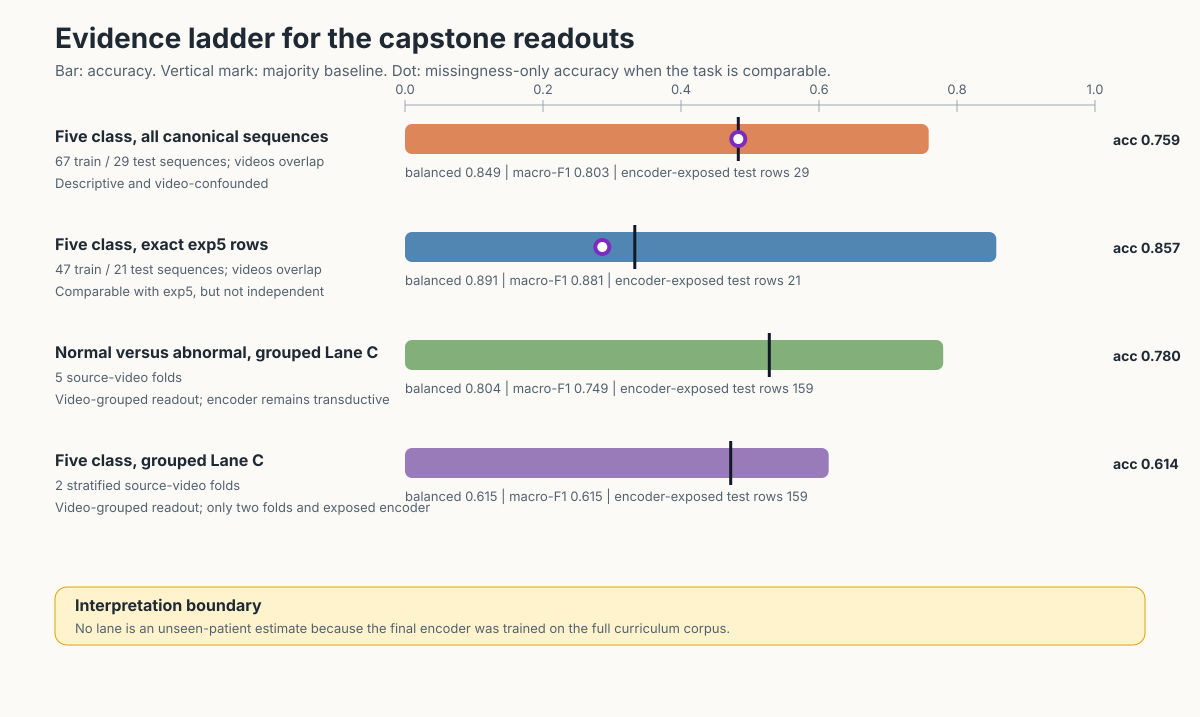

In [24]:
from xml.sax.saxutils import escape

svg_width = 1200
row_height = 108
svg_height = 190 + row_height * len(results_summary) + 95
bar_x = 405
bar_width = 690
colors = ["#d97745", "#3977a8", "#72a66a", "#8c6bb1"]

svg_parts = [
    f'<svg xmlns="http://www.w3.org/2000/svg" width="{svg_width}" '
    f'height="{svg_height}" viewBox="0 0 {svg_width} {svg_height}">',
    '<rect width="100%" height="100%" fill="#fbfaf7"/>',
    '<style>',
    'text{font-family:Inter,Arial,sans-serif;fill:#1f2933}',
    '.title{font-size:28px;font-weight:700}',
    '.subtitle{font-size:15px;fill:#52606d}',
    '.label{font-size:16px;font-weight:650}',
    '.small{font-size:13px;fill:#52606d}',
    '.value{font-size:14px;font-weight:650}',
    '</style>',
    '<text x="55" y="48" class="title">Evidence ladder for the capstone readouts</text>',
    '<text x="55" y="76" class="subtitle">Bar: accuracy. Vertical mark: majority baseline. Dot: missingness-only accuracy when the task is comparable.</text>',
    f'<line x1="{bar_x}" y1="105" x2="{bar_x + bar_width}" y2="105" stroke="#9aa5b1"/>',
]

for tick in np.linspace(0, 1, 6):
    x = bar_x + tick * bar_width
    svg_parts.extend([
        f'<line x1="{x:.1f}" y1="100" x2="{x:.1f}" y2="112" stroke="#9aa5b1"/>',
        f'<text x="{x:.1f}" y="94" class="small" text-anchor="middle">{tick:.1f}</text>',
    ])

for index, row in results_summary.reset_index(drop=True).iterrows():
    y = 142 + index * row_height
    accuracy = float(row["accuracy"])
    majority = float(row["majority_accuracy"])
    missingness = row["missingness_accuracy"]
    color = colors[index % len(colors)]
    svg_parts.extend([
        f'<text x="55" y="{y}" class="label">{escape(str(row["analysis"]))}</text>',
        f'<text x="55" y="{y + 24}" class="small">{escape(str(row["readout_split"]))}</text>',
        f'<text x="55" y="{y + 46}" class="small">{escape(str(row["interpretation"]))}</text>',
        f'<rect x="{bar_x}" y="{y - 18}" width="{accuracy * bar_width:.1f}" height="30" rx="7" fill="{color}" opacity="0.88"/>',
        f'<line x1="{bar_x + majority * bar_width:.1f}" y1="{y - 25}" x2="{bar_x + majority * bar_width:.1f}" y2="{y + 19}" stroke="#111827" stroke-width="3"/>',
        f'<text x="{bar_x + bar_width + 18}" y="{y + 3}" class="value">acc {accuracy:.3f}</text>',
        f'<text x="{bar_x}" y="{y + 35}" class="small">balanced {float(row["balanced_accuracy"]):.3f} | macro-F1 {float(row["macro_f1"]):.3f} | encoder-exposed test rows {int(row["test_rows_seen_by_encoder"])}</text>',
    ])
    if pd.notna(missingness):
        missing_x = bar_x + float(missingness) * bar_width
        svg_parts.append(
            f'<circle cx="{missing_x:.1f}" cy="{y - 3}" r="7" fill="#ffffff" stroke="#7b2cbf" stroke-width="4"/>'
        )

caution_y = 155 + len(results_summary) * row_height
svg_parts.extend([
    f'<rect x="55" y="{caution_y}" width="1090" height="58" rx="12" fill="#fff3cd" stroke="#d6a700"/>',
    f'<text x="75" y="{caution_y + 24}" class="label">Interpretation boundary</text>',
    f'<text x="75" y="{caution_y + 46}" class="small">No lane is an unseen-patient estimate because the final encoder was trained on the full curriculum corpus.</text>',
    '</svg>',
])

results_svg = "".join(svg_parts)
(ARTIFACT_DIR / "capstone_results_evidence_ladder.svg").write_text(
    results_svg, encoding="utf-8"
)
display(SVG(results_svg))

In [25]:
all_correct = int(np.trace(all_sequence_confusion))
exp5_correct = int(np.trace(five_class_confusion))
all_total = int(all_sequence_confusion.sum())
exp5_total = int(five_class_confusion.sum())
all_majority = majority_accuracy(labels[all_test_index])
exp5_majority = majority_accuracy(labels[test_index])

all_gap_over_missingness = (
    all_sequence_metrics["accuracy"] - all_missingness_metrics["accuracy"]
)
exp5_gap_over_missingness = (
    five_class_metrics["accuracy"] - exp5_missingness_metrics["accuracy"]
)
exp5_gap_over_handcrafted = (
    five_class_metrics["accuracy"] - HANDCRAFTED_EXP5_ACCURACY
)
exp5_f1_gap_over_handcrafted = (
    five_class_metrics["macro_f1"] - HANDCRAFTED_EXP5_MACRO_F1
)

lane_c_discussion = (
    "Lane C was not run because the augmentation cohort was disabled or the "
    "source-video requirements were not met."
)
if grouped_metrics is not None and len(grouped_metrics):
    binary_row = grouped_metrics.loc[
        grouped_metrics["task"] == "normal_vs_abnormal_video_disjoint"
    ]
    five_row = grouped_metrics.loc[
        grouped_metrics["task"]
        == "five_class_classifier_video_disjoint_encoder_transductive"
    ]
    lane_c_parts = []
    if len(binary_row):
        row = binary_row.iloc[0]
        lane_c_parts.append(
            "The grouped normal-versus-abnormal readout used "
            f"{int(row['n_folds'])} source-video folds across "
            f"{int(row['n_sequences'])} sequences. Mean accuracy was "
            f"{row['accuracy_mean']:.3f} with a fold-bootstrap 95% interval "
            f"from {row['accuracy_ci_low']:.3f} to {row['accuracy_ci_high']:.3f}. "
            f"Mean balanced accuracy was {row['balanced_accuracy_mean']:.3f}, "
            f"mean macro-F1 was {row['macro_f1_mean']:.3f}, and mean ROC-AUC "
            f"was {row['roc_auc_mean']:.3f}. The accuracy exceeded the binary "
            f"majority baseline of {row['majority_class_baseline']:.3f}."
        )
    if len(five_row):
        row = five_row.iloc[0]
        lane_c_parts.append(
            "The grouped five-class stress test used only "
            f"{int(row['n_folds'])} folds because Parkinson's and cerebral "
            "palsy each have only two source videos. Mean accuracy was "
            f"{row['accuracy_mean']:.3f}, mean balanced accuracy was "
            f"{row['balanced_accuracy_mean']:.3f}, and mean macro-F1 was "
            f"{row['macro_f1_mean']:.3f}. Pooled out-of-fold accuracy was "
            f"{row['accuracy_pooled_oof']:.3f} and pooled macro-F1 was "
            f"{row['macro_f1_pooled_oof']:.3f}."
        )
    lane_c_parts.append(
        "Every Lane C test sequence had already contributed to representation "
        "training. Grouping therefore removes source-video overlap from the "
        "Random Forest split, but it does not remove exposure from the encoder."
    )
    lane_c_discussion = " ".join(lane_c_parts)

binary_summary = ", ".join(
    f"{row.condition_vs_normal}: {row.accuracy:.3f} accuracy on "
    f"{int(row.test_sequences)} test sequences"
    for row in binary_metrics.itertuples()
)

discussion = f"""
### What the current numbers show

**The frozen embeddings contain substantial dataset-label structure.** On the all-96 sequence split, the Random Forest classified {all_correct} of {all_total} held-out rows correctly. Accuracy was {all_sequence_metrics['accuracy']:.3f}, balanced accuracy was {all_sequence_metrics['balanced_accuracy']:.3f}, and macro-F1 was {all_sequence_metrics['macro_f1']:.3f}. Accuracy was {all_gap_over_missingness:.3f} higher than the missingness-only control. The control accuracy of {all_missingness_metrics['accuracy']:.3f} was close to the test-set majority baseline of {all_majority:.3f}. This gap supports the claim that the pooled embeddings contain information beyond detector visibility patterns.

**The exact exp5 comparison gives the strongest descriptive score, but it is still confounded.** The S-JEPA readout classified {exp5_correct} of {exp5_total} test rows correctly. Accuracy was {five_class_metrics['accuracy']:.3f}, balanced accuracy was {five_class_metrics['balanced_accuracy']:.3f}, and macro-F1 was {five_class_metrics['macro_f1']:.3f}. The missingness-only control reached {exp5_missingness_metrics['accuracy']:.3f} accuracy, so the latent readout was higher by {exp5_gap_over_missingness:.3f}. Relative to the saved 82-feature handcrafted reference on the same row split, latent accuracy was higher by {exp5_gap_over_handcrafted:.3f} and macro-F1 was higher by {exp5_f1_gap_over_handcrafted:.3f}. This is a system-level comparison because pose extraction and feature construction also differ. It does not isolate the causal effect of S-JEPA.

**The errors are concentrated in clinically related dataset categories rather than spread uniformly.** In the all-96 split, normal, Parkinson's, and stroke each had recall 1.000. Cerebral palsy recall was {all_sequence_report.loc['cerebralpalsy', 'recall']:.3f}, and myopathic recall was {all_sequence_report.loc['myopathic', 'recall']:.3f}. The confusion table shows that most mistakes involved cerebral palsy, myopathic gait, and stroke. This pattern is compatible with overlapping movement characteristics, but the small supports do not justify a clinical interpretation.

**The binary results are useful as a separability check, not as evidence of perfect diagnosis.** The four one-versus-normal readouts produced the following results: {binary_summary}. These test sets contain only 7 to 18 sequences, their source videos overlap with training, and the encoder was trained with condition-aware objectives after Stage 0. Perfect scores under those conditions are a warning about dependence and small samples, not proof of deployment-level performance.

### What source-video grouping changes

{lane_c_discussion}

### Shortcut evidence

The missingness-only controls use 97 visibility features and no pose coordinates. Their five-class accuracies were {all_missingness_metrics['accuracy']:.3f} on the all-96 split and {exp5_missingness_metrics['accuracy']:.3f} on the exact exp5 split. These values show that detector behavior carries some condition-related structure. However, both controls were well below the corresponding latent readouts. The safe conclusion is that missingness does not explain all of the observed separation. It may still contribute to individual predictions because validity patterns can enter the Transformer through neighboring tokens.

### Evidence-supported conclusion

The completed five-stage encoder, identified by fingerprint `{checkpoint['dataset_fingerprint'][:16]}`, produces 384-feature sequence embeddings from the authorized 12-keypoint set. A shallow Random Forest can recover the five folder labels from these embeddings more accurately than majority and missingness-only controls in the tested descriptive splits. The grouped Lane C results also show that the readout retains useful separation when complete videos are assigned to different classifier folds.

The evidence does not establish generalization to an unseen patient, an unseen recording setting, or an encoder-naive source video. All reported test sequences were visible during representation training, and Stages 1 through 4 used label-aware group loss. The next valid experiment must train the complete five-stage encoder separately inside every outer source-video training fold. Until that nested experiment is completed, these results should be described as exploratory, transductive, and non-diagnostic.
"""

display(Markdown(discussion))


### What the current numbers show

**The frozen embeddings contain substantial dataset-label structure.** On the all-96 sequence split, the Random Forest classified 22 of 29 held-out rows correctly. Accuracy was 0.759, balanced accuracy was 0.849, and macro-F1 was 0.803. Accuracy was 0.276 higher than the missingness-only control. The control accuracy of 0.483 was close to the test-set majority baseline of 0.483. This gap supports the claim that the pooled embeddings contain information beyond detector visibility patterns.

**The exact exp5 comparison gives the strongest descriptive score, but it is still confounded.** The S-JEPA readout classified 18 of 21 test rows correctly. Accuracy was 0.857, balanced accuracy was 0.891, and macro-F1 was 0.881. The missingness-only control reached 0.286 accuracy, so the latent readout was higher by 0.571. Relative to the saved 82-feature handcrafted reference on the same row split, latent accuracy was higher by 0.095 and macro-F1 was higher by 0.153. This is a system-level comparison because pose extraction and feature construction also differ. It does not isolate the causal effect of S-JEPA.

**The errors are concentrated in clinically related dataset categories rather than spread uniformly.** In the all-96 split, normal, Parkinson's, and stroke each had recall 1.000. Cerebral palsy recall was 0.600, and myopathic recall was 0.643. The confusion table shows that most mistakes involved cerebral palsy, myopathic gait, and stroke. This pattern is compatible with overlapping movement characteristics, but the small supports do not justify a clinical interpretation.

**The binary results are useful as a separability check, not as evidence of perfect diagnosis.** The four one-versus-normal readouts produced the following results: parkinsons: 1.000 accuracy on 7 test sequences, stroke: 1.000 accuracy on 7 test sequences, myopathic: 1.000 accuracy on 18 test sequences, cerebralpalsy: 1.000 accuracy on 9 test sequences. These test sets contain only 7 to 18 sequences, their source videos overlap with training, and the encoder was trained with condition-aware objectives after Stage 0. Perfect scores under those conditions are a warning about dependence and small samples, not proof of deployment-level performance.

### What source-video grouping changes

The grouped normal-versus-abnormal readout used 5 source-video folds across 159 sequences. Mean accuracy was 0.780 with a fold-bootstrap 95% interval from 0.731 to 0.830. Mean balanced accuracy was 0.804, mean macro-F1 was 0.749, and mean ROC-AUC was 0.915. The accuracy exceeded the binary majority baseline of 0.528. The grouped five-class stress test used only 2 folds because Parkinson's and cerebral palsy each have only two source videos. Mean accuracy was 0.614, mean balanced accuracy was 0.615, and mean macro-F1 was 0.615. Pooled out-of-fold accuracy was 0.616 and pooled macro-F1 was 0.610. Every Lane C test sequence had already contributed to representation training. Grouping therefore removes source-video overlap from the Random Forest split, but it does not remove exposure from the encoder.

### Shortcut evidence

The missingness-only controls use 97 visibility features and no pose coordinates. Their five-class accuracies were 0.483 on the all-96 split and 0.286 on the exact exp5 split. These values show that detector behavior carries some condition-related structure. However, both controls were well below the corresponding latent readouts. The safe conclusion is that missingness does not explain all of the observed separation. It may still contribute to individual predictions because validity patterns can enter the Transformer through neighboring tokens.

### Evidence-supported conclusion

The completed five-stage encoder, identified by fingerprint `ea59fea055f0230b`, produces 384-feature sequence embeddings from the authorized 12-keypoint set. A shallow Random Forest can recover the five folder labels from these embeddings more accurately than majority and missingness-only controls in the tested descriptive splits. The grouped Lane C results also show that the readout retains useful separation when complete videos are assigned to different classifier folds.

The evidence does not establish generalization to an unseen patient, an unseen recording setting, or an encoder-naive source video. All reported test sequences were visible during representation training, and Stages 1 through 4 used label-aware group loss. The next valid experiment must train the complete five-stage encoder separately inside every outer source-video training fold. Until that nested experiment is completed, these results should be described as exploratory, transductive, and non-diagnostic.


## Summary: what was established, what remains open, and what comes next

### Final interpretation guide

The results support a narrow but useful conclusion. The learned representation contains condition-associated structure that a shallow classifier can recover and that pose-detector missingness does not explain. The evidence is strongest as a **representation audit** and weakest as a claim about future patients.

### The following statements are supported

1. The final curriculum encoder did not collapse into an uninformative representation.
2. Its embeddings recover the five dataset labels better than the majority-class and missingness-only references on every evaluated split: 0.759 against floors of 0.483 and 0.483 on all 96 canonical rows, 0.857 against 0.333 and 0.286 on the exact exp5 rows, and 0.614 against 0.472 in the grouped five-class Lane C.
3. Normal-versus-abnormal separation persists when the Random Forest uses source-video-grouped folds, at 0.780 mean accuracy against a binary majority floor of 0.528.
4. The five-class readout **degrades but survives** grouping, from 0.759 to 0.614 accuracy and from 0.803 to 0.615 macro-F1, which quantifies roughly how much of the sequence-level score was video confounding.
5. The hardest five-class confusions are concentrated among cerebral palsy, myopathic gait, and stroke in the current test rows, consistent with notebook 05's finding that the closest condition centroids are only 0.026 apart.

### The following statements are not supported

1. The model has **not** demonstrated diagnostic validity. Nothing here is clinical validation.
2. The model has **not** demonstrated generalization to unseen patients, unseen videos, or unseen recording environments. Every reported test row was visible during representation training, and Stages 1 through 4 used a label-aware group loss.
3. The experiments do **not** prove that S-JEPA caused the improvement over the handcrafted system, because pose extraction and feature construction also differ.
4. The perfect one-versus-normal scores must **not** be treated as expected production performance. Their test sets hold 7 to 18 sequences, their videos overlap training, and normal comes from one source video.
5. Nothing here is evidence of clean five-condition geometry. Notebook 05 measured a cosine silhouette of 0.054 on this same representation.

### What each lane licensed, in one line each

- **Lane A1** licensed a descriptive statement about label recoverability on a fixed sequence partition, with 16 of 16 test videos and 29 of 29 test rows exposed.
- **Lane A2** licensed a like-for-like row comparison with exp5, and nothing more, because it is video-confounded and encoder-exposed.
- **Lane B** licensed nothing, because it could not run: canonical normal has one source video. This is recorded, not omitted.
- **Lane C** licensed a statement that the readout survives classifier-level video grouping, while all 159 of its rows remained encoder-exposed and its five-class arm rested on two folds.
- **The missingness-only control** licensed the statement that detector-failure patterns do not explain the separation, since it reached only 0.483 and 0.286 against latent readouts of 0.759 and 0.857.

### What remains open, and the study that would close it

A defensible next study must use **nested source-video evaluation**. Concretely:

1. Each outer fold excludes its test videos **before** pose-derived representation training begins, not after.
2. Notebook 04 then trains all five curriculum stages using only that fold's training videos, including Stage 0, VICReg, and the label-aware group loss.
3. The Random Forest and every preprocessing choice are fitted inside that same fold.
4. Reporting includes pooled out-of-fold predictions, class-wise confidence intervals, missingness controls, and repeated grouped splits where the number of independent videos permits them.

Until that nested experiment is completed, every result in notebooks 04 through 06 should be described as **exploratory, transductive, and non-diagnostic**. The binding constraint is the cohort: 35 source videos in total, with Parkinson's and cerebral palsy at two each, and normal at one in the canonical corpus. More sequences from the same uploads will not fix that. More independent source videos would.
